[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/evinracher/3008338-geospatial-analysis/blob/main/project/house-price-medellin.ipynb)

# Introduccción

En este notebook se presenta el desarrollo de un proyecto para predecir el precio de las viviendas en Medellín. Se presenta una comparación de diferentes modelos espaciales, entrenados en un dataset disponible en Kaggle, que recopila la información de varias viviendas en Colombia. Adicionalmente se presenta una comparación con modelos de machine learning tradicionales. El dataset incluye información como número de habitaciones, número de baños, área total del inmueble y precio.

Para realizar este proyecto, se filtró la información solo de los inmuebles ubicados en Medellín y se hizo el procesamiento de datos adecuado para filtrar registros con información faltante o datos errados.


Dataset principal: https://www.kaggle.com/datasets/julianusugaortiz/colombia-housing-properties-price

In [422]:
%matplotlib inline
# needed in jupyter notebook
import matplotlib.pyplot as plt

# Carga de datos

Se cargan los datos desde Kaggle directamente, usando la API de Kaggle

In [423]:
# Instalando las dependencias necesarias
%pip install kagglehub scikit-learn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [424]:
# Requires libomp: On Mac, you can install it running: brew install libomp
%pip install xgboost


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [425]:
from pathlib import Path

import kagglehub
import pandas as pd

# Download latest version
dataset_path = Path(
    kagglehub.dataset_download("julianusugaortiz/colombia-housing-properties-price")
)

print("Path to dataset files:", dataset_path)

# Find and load the CSV file
csv_files = list(dataset_path.glob("*.csv"))
print("CSV files:", [file.name for file in csv_files])

csv_path = dataset_path / "co_properties.csv"
df = pd.read_csv(csv_path)

df.head()

Path to dataset files: /Users/kevin.parra/.cache/kagglehub/datasets/julianusugaortiz/colombia-housing-properties-price/versions/2
CSV files: ['co_properties.csv']


,id,ad_type,start_date,end_date,created_on,lat,lon,l1,l2,l3,...,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type
0,KsjahK62rxcYKXXQjOdkqw==,Propiedad,2020-10-07,2021-10-09,2020-10-07,3.9210,-76.506000,Colombia,Valle del Cauca,NaN,...,7.0,NaN,NaN,1.300000e+09,COP,NaN,Casa Campestre en venta en darien 3469064,"HERMOSA CASA CAMPESTRE, &Aacute;REA 6,000 MT, ...",Casa,Venta
1,Y+gsBZYq1zu5NoR3V5oUGA==,Propiedad,2020-10-07,2021-01-06,2020-10-07,3.3577,-76.541811,Colombia,Valle del Cauca,Cali,...,7.0,NaN,NaN,2.800000e+09,COP,NaN,Casa en ciudsd jardin,Casa independiente con posiciona en ciudad jar...,Casa,Venta
2,Jpzqxj8/Vgf3Aa5ASxUBNg==,Propiedad,2020-10-07,2020-10-07,2020-10-07,3.3577,-76.541811,Colombia,Valle del Cauca,Cali,...,7.0,NaN,NaN,2.800000e+09,COP,Mensual,Casa en ciudsd jardin,Casa independiente con posiciona en ciudad jar...,Casa,Venta
3,ieuFnkFx/yHDD66iMV14Gw==,Propiedad,2020-10-07,2021-04-12,2020-10-07,3.3640,-76.538000,Colombia,Valle del Cauca,Cali,...,8.0,NaN,NaN,3.500000e+09,COP,NaN,Casa en venta en pance 1630426,"EXCELENTE CASA - LOTE 6,373 MT, EN OBRA GRIS U...",Casa,Venta
4,g4u5JM+hAHEk8SukRSjMzg==,Propiedad,2020-10-07,9999-12-31,2020-10-07,3.3910,-76.517000,Colombia,Valle del Cauca,Cali,...,9.0,NaN,NaN,4.800000e+08,COP,NaN,CASA EXTERNA BARRIO CIUDAD 2000,"CASA EXTERNA EN EL BARRIO CIUDAD 2000,CONSTRUI...",Casa,Venta


# Procesamiento y exploración de los datos

El dataset tiene varias características que no son importantes para el problema, como la columna l1, que representa el país donde está ubicado el inmueble y para la cual todos los registros tienen el valor de "Colombia". Así mismo, ad_type, que tiene el mismo valor para todos los registros y no aporta ningún valor a los modelos.

Por lo tanto, se van a eliminar esas columnas

In [426]:
columns_to_keep = [
    "lat",
    "lon",
    "l3",
    "l4",
    "l5",
    "l6",
    "rooms",
    "bedrooms",
    "bathrooms",
    "surface_total",
    "surface_covered",
    "price",
    "title",
    "property_type",
    "operation_type",
]

discarded_columns = [col for col in df.columns if col not in columns_to_keep]

df_selected = df[columns_to_keep].copy()

print("Discarded columns:")
print(discarded_columns)

df_selected.head()

Discarded columns:
['id', 'ad_type', 'start_date', 'end_date', 'created_on', 'l1', 'l2', 'currency', 'price_period', 'description']


,lat,lon,l3,l4,l5,l6,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,title,property_type,operation_type
0,3.9210,-76.506000,NaN,NaN,NaN,NaN,NaN,6.0,7.0,NaN,NaN,1.300000e+09,Casa Campestre en venta en darien 3469064,Casa,Venta
1,3.3577,-76.541811,Cali,Ciudad Jardín,NaN,NaN,NaN,NaN,7.0,NaN,NaN,2.800000e+09,Casa en ciudsd jardin,Casa,Venta
2,3.3577,-76.541811,Cali,Ciudad Jardín,NaN,NaN,NaN,NaN,7.0,NaN,NaN,2.800000e+09,Casa en ciudsd jardin,Casa,Venta
3,3.3640,-76.538000,Cali,Ciudad Jardín,NaN,NaN,NaN,5.0,8.0,NaN,NaN,3.500000e+09,Casa en venta en pance 1630426,Casa,Venta
4,3.3910,-76.517000,Cali,NaN,NaN,NaN,NaN,8.0,9.0,NaN,NaN,4.800000e+08,CASA EXTERNA BARRIO CIUDAD 2000,Casa,Venta


A continuación se presenta el significado de algunas columnas:

l1: País

l2: Departamento

l3: Cuidad

l4: Zona

l5: Localidad

l6: Barrio (Neighborhood)

Vamos a explorar los valores de estas columnas y ver si nos pueden aportar algo o por el contrario las podemos eliminar, recordando que se utilizarán solo los datos de inmuebles en Medellín

In [427]:
for col in ["l3", "l4", "l5", "l6"]:
    print(f"\nUnique values in {col}:")
    print(df_selected[col].dropna().unique())
    print(f"Total unique values: {df_selected[col].nunique(dropna=True)}")


Unique values in l3:
<StringArray>
[                'Cali',                 'Chía',                'Dagua',
              'Pereira',              'Jamundí',             'Restrepo',
            'Manizales',             'Medellín',           'Bogotá D.C',
          'Santa Marta',
 ...
              'Quipile', 'El Carmen de Bolívar',              'Caqueza',
           'Caicedonia',              'Fúquene',              'Buesaco',
              'Yaguará',          'Nuevo Colón',               'Sotara',
                'Ataco']
Length: 343, dtype: str
Total unique values: 343

Unique values in l4:
<StringArray>
[         'Ciudad Jardín',     'San Fernando Nuevo',               'Laureles',
     'Zona Noroccidental',        'Zona Occidental',         'Zona Chapinero',
                  'Caney',                   'Lili',        'Doce de Octubre',
             'La América',                  'Belén',             'El Poblado',
          'Villa Hermosa',             'Zona Norte',     'Zona Surocci

Sin duda estas columnas tienen bastantes valores únicos, representando diferentes barrios y localidades.

## Filtrando los datos de solo Medellín

Sin embargo, nuestro interés es filtrar solo la información de Medellín, vamos a filtrar el dataset para obtener solo los datos que nos interesan.

In [428]:
df_medellin = df_selected[df_selected["l3"] == "Medellín"].copy()

print("Medellín dataset shape:", df_medellin.shape)

df_medellin.head()

Medellín dataset shape: (262856, 15)


,lat,lon,l3,l4,l5,l6,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,title,property_type,operation_type
46,NaN,NaN,Medellín,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,4.000000e+09,Casa en Venta Ubicado en MEDELLIN,Casa,Venta
47,6.238637,-75.602011,Medellín,Laureles,NaN,NaN,NaN,19.0,20.0,NaN,NaN,1.300000e+07,"CASA EN ARRIENDO, MEDELLIN-LAURELES",Casa,Arriendo
48,NaN,NaN,Medellín,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,1.500000e+07,Casa en Arriendo Ubicado en MEDELLIN,Casa,Arriendo
157,6.297802,-75.577835,Medellín,Doce de Octubre,NaN,NaN,5.0,5.0,NaN,NaN,NaN,3.100000e+08,Venta de casa en Florencia,Casa,Venta
158,6.245972,-75.614730,Medellín,La América,NaN,NaN,7.0,7.0,NaN,NaN,NaN,2.500000e+06,Arriendo Casa Duplex en Santa Monica,Casa,Arriendo


In [429]:
for col in ["l4", "l5", "l6"]:
    print(f"\nUnique values in {col}:")
    print(df_medellin[col].unique())
    print(f"Total unique values: {df_medellin[col].nunique()}")


Unique values in l4:
<StringArray>
[                   nan,             'Laureles',      'Doce de Octubre',
           'La América',                'Belén',           'El Poblado',
        'Villa Hermosa',              'Robledo',             'Castilla',
           'San Javier',        'San Cristóbal',           'Santa Cruz',
          'Santa Elena',             'Guayabal',             'Aranjuez',
           'Candelaria',            'Altavista',             'Manrique',
         'Buenos Aires',              'Popular', 'San Antonio de Prado',
             'Palmitas']
Length: 22, dtype: str
Total unique values: 21

Unique values in l5:
<StringArray>
[nan]
Length: 1, dtype: str
Total unique values: 0

Unique values in l6:
<StringArray>
[nan]
Length: 1, dtype: str
Total unique values: 0


Vemos que para Medellín, las columnas l5 y l6 no tienen ningún valor representativo, por tanto vamos a eliminarlas.

In [430]:
df_medellin = df_medellin.drop(columns=["l5", "l6"])

print("Medellín dataset shape after dropping l5 and l6:", df_medellin.shape)
print("Remaining columns:")
print(df_medellin.columns.tolist())

df_medellin.head()

Medellín dataset shape after dropping l5 and l6: (262856, 13)
Remaining columns:
['lat', 'lon', 'l3', 'l4', 'rooms', 'bedrooms', 'bathrooms', 'surface_total', 'surface_covered', 'price', 'title', 'property_type', 'operation_type']


,lat,lon,l3,l4,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,title,property_type,operation_type
46,NaN,NaN,Medellín,NaN,NaN,NaN,8.0,NaN,NaN,4.000000e+09,Casa en Venta Ubicado en MEDELLIN,Casa,Venta
47,6.238637,-75.602011,Medellín,Laureles,NaN,19.0,20.0,NaN,NaN,1.300000e+07,"CASA EN ARRIENDO, MEDELLIN-LAURELES",Casa,Arriendo
48,NaN,NaN,Medellín,NaN,NaN,NaN,7.0,NaN,NaN,1.500000e+07,Casa en Arriendo Ubicado en MEDELLIN,Casa,Arriendo
157,6.297802,-75.577835,Medellín,Doce de Octubre,5.0,5.0,NaN,NaN,NaN,3.100000e+08,Venta de casa en Florencia,Casa,Venta
158,6.245972,-75.614730,Medellín,La América,7.0,7.0,NaN,NaN,NaN,2.500000e+06,Arriendo Casa Duplex en Santa Monica,Casa,Arriendo


In [431]:
print("Operation types")
print(df_medellin["operation_type"].dropna().unique())

Operation types
<StringArray>
['Venta', 'Arriendo', 'Arriendo temporal']
Length: 3, dtype: str


In [432]:
# Cantidad de registros por tipo de operación
print("\nRecords by operation type")
print(df_medellin["operation_type"].value_counts(dropna=False))


Records by operation type
operation_type
Arriendo             143439
Venta                119394
Arriendo temporal        23
Name: count, dtype: int64


In [433]:
print(df_medellin["property_type"].unique())

<StringArray>
[           'Casa',            'Lote',            'Otro',         'Oficina',
     'Apartamento', 'Local comercial',           'Finca',        'Depósito',
     'Parqueadero']
Length: 9, dtype: str


Así mismo, vemos que hay dos tipos de operaciones en el dataset: Venta y arriendo. En este proyecto nos enfocaremos solo en el precio de venta de un inmueble. Por tanto, vamos a filtrar solo por este tipo de operación

In [434]:
df_medellin = df_medellin[df_medellin["operation_type"] == "Venta"].copy()

df_medellin.drop(columns=["operation_type"], inplace=True)

Eliminamos adicionalmente otras columnas cuyos valores se repiten (en este caso, l3 que representa la ciudad y para nuestro subconjunto es la misma, Medellín); así mismo eliminamos columnas que no aportan mucho valor a nuestro problema:

In [435]:
df_medellin_clean = df_medellin.drop(columns=["l3", "title"]).copy()

In [436]:
df_medellin_clean.describe()

,lat,lon,rooms,bedrooms,bathrooms,surface_total,surface_covered,price
count,36540.000000,36540.000000,11889.000000,20456.000000,102697.000000,1356.000000,1442.000000,1.193700e+05
mean,6.214631,-75.561639,3.097906,2.995991,2.477677,498.648968,323.671290,5.644555e+08
std,1.130376,1.162069,1.300625,1.316010,1.290765,3172.582247,2902.863675,1.732681e+09
min,-75.580770,-97.494152,1.000000,0.000000,1.000000,11.000000,1.000000,0.000000e+00
25%,6.204034,-75.597782,3.000000,3.000000,2.000000,74.000000,74.000000,2.400000e+08
50%,6.228191,-75.577156,3.000000,3.000000,2.000000,120.000000,120.000000,3.450000e+08
75%,6.251000,-75.564960,3.000000,3.000000,3.000000,206.250000,200.000000,6.000000e+08
max,51.801231,14.154488,31.000000,41.000000,20.000000,83333.000000,105372.000000,4.650000e+11


In [437]:
df_medellin_clean.info()

<class 'pandas.DataFrame'>
Index: 119394 entries, 46 to 999044
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   lat              36540 non-null   float64
 1   lon              36540 non-null   float64
 2   l4               36417 non-null   str    
 3   rooms            11889 non-null   float64
 4   bedrooms         20456 non-null   float64
 5   bathrooms        102697 non-null  float64
 6   surface_total    1356 non-null    float64
 7   surface_covered  1442 non-null    float64
 8   price            119370 non-null  float64
 9   property_type    119394 non-null  str    
dtypes: float64(8), str(2)
memory usage: 10.0 MB


Mirando la información de las columnas, vemos que la mayoría tiene valores nulos para lat y lon y las demás variables.

In [438]:
df_medellin_clean = df_medellin_clean[df_medellin_clean["lat"].notna()].copy()
df_medellin_clean.head()

,lat,lon,l4,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,property_type
157,6.297802,-75.577835,Doce de Octubre,5.0,5.0,NaN,NaN,NaN,3.100000e+08,Casa
160,6.307000,-75.579002,Doce de Octubre,NaN,NaN,NaN,NaN,NaN,1.500000e+08,Casa
161,6.201145,-75.565205,El Poblado,3.0,3.0,NaN,NaN,NaN,1.250000e+09,Casa
162,6.256467,-75.557640,Villa Hermosa,6.0,6.0,NaN,NaN,NaN,1.800000e+08,Casa
345,6.259253,-75.628381,San Javier,NaN,NaN,1.0,NaN,NaN,3.800000e+07,Casa


Vemos que para ciertos features como surface_covered, lat, y lon, el valor no se tiene el valor disponible. Más adelante se tratatará ese caso, por ahora separemos los datos.

In [439]:
# Renombramos L4
df_medellin_clean.rename(columns={"l4": "neighborhood"}, inplace=True)

Por último, miremos si hay registros que no tengan el precio asignado

In [440]:
df_medellin_clean["price"][df_medellin["price"].isna()]

122402   NaN
176430   NaN
228065   NaN
228725   NaN
229994   NaN
240100   NaN
297577   NaN
299789   NaN
299979   NaN
304090   NaN
315120   NaN
333004   NaN
394965   NaN
502051   NaN
537055   NaN
772402   NaN
Name: price, dtype: float64

Son pocos registros, por lo tanto, se eliminarán estos registros para evitar errores en el entrenamiento:

In [441]:
df_medellin_clean = df_medellin_clean[df_medellin_clean["price"].notna()].copy()

In [442]:
df_medellin_clean.info()

<class 'pandas.DataFrame'>
Index: 36524 entries, 157 to 999044
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   lat              36524 non-null  float64
 1   lon              36524 non-null  float64
 2   neighborhood     35936 non-null  str    
 3   rooms            11795 non-null  float64
 4   bedrooms         19199 non-null  float64
 5   bathrooms        24974 non-null  float64
 6   surface_total    1311 non-null   float64
 7   surface_covered  1392 non-null   float64
 8   price            36524 non-null  float64
 9   property_type    36524 non-null  str    
dtypes: float64(8), str(2)
memory usage: 3.1 MB


Guardamos el dataset con las modificaciones hechas en un archivo .csv y lo cargamos nuevamente, esto con el fin de facilitar el flujo de trabajo y la reproducibilidad de este notebook:

In [443]:
from pathlib import Path

dataset_dir = Path("dataset")
dataset_dir.mkdir(exist_ok=True)

output_path = dataset_dir / "final_dataset.csv"
df_medellin_clean.to_csv(output_path, index=False)

print(f"Saved df_medellin to: {output_path}")

Saved df_medellin to: dataset/final_dataset.csv


In [444]:
import pandas as pd
df_medellin_clean = pd.read_csv("./dataset/final_dataset.csv")
df_medellin_clean.head()

,lat,lon,neighborhood,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,property_type
0,6.297802,-75.577835,Doce de Octubre,5.0,5.0,NaN,NaN,NaN,3.100000e+08,Casa
1,6.307000,-75.579002,Doce de Octubre,NaN,NaN,NaN,NaN,NaN,1.500000e+08,Casa
2,6.201145,-75.565205,El Poblado,3.0,3.0,NaN,NaN,NaN,1.250000e+09,Casa
3,6.256467,-75.557640,Villa Hermosa,6.0,6.0,NaN,NaN,NaN,1.800000e+08,Casa
4,6.259253,-75.628381,San Javier,NaN,NaN,1.0,NaN,NaN,3.800000e+07,Casa


In [445]:
df_medellin_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 36524 entries, 0 to 36523
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   lat              36524 non-null  float64
 1   lon              36524 non-null  float64
 2   neighborhood     35936 non-null  str    
 3   rooms            11795 non-null  float64
 4   bedrooms         19199 non-null  float64
 5   bathrooms        24974 non-null  float64
 6   surface_total    1311 non-null   float64
 7   surface_covered  1392 non-null   float64
 8   price            36524 non-null  float64
 9   property_type    36524 non-null  str    
dtypes: float64(8), str(2)
memory usage: 2.8 MB


Vamos a manejar los outliers en el precio, ya que hay valores muy altos, que se alejan de los demás valores para esta característica:

In [446]:
q99 = df_medellin_clean["price"].quantile(0.99)
df_medellin_clean = df_medellin_clean[df_medellin_clean["price"] <= q99].copy()

Así mismo, se deben manejar los valores bajos, pues vemos que hay un registros que tienen un precio muy bajo:

In [447]:
q01 = df_medellin_clean["price"].quantile(0.01)
df_medellin_clean = df_medellin_clean[df_medellin_clean["price"] >= q01].copy()

## Análisis final del dataset a utilizar

Una vez hechas todo el procesamiento pertinente de los datos, manejado los outliers, eliminado las columnas que no nos interesan para nuestro problema y demás filtros necesarios, hagamos un análisis y exploración final de los datos

In [448]:
df_medellin_clean.describe()

,lat,lon,rooms,bedrooms,bathrooms,surface_total,surface_covered,price
count,35814.000000,35814.000000,11700.000000,19006.000000,24568.000000,1275.000000,1358.000000,3.581400e+04
mean,6.221088,-75.568215,3.076667,2.983952,2.582628,387.253333,278.961708,5.948796e+08
std,0.862014,0.903975,1.162725,1.199186,1.277321,2785.493727,2915.710771,5.552808e+08
min,-75.580770,-97.494152,1.000000,0.000000,1.000000,11.000000,1.000000,8.200000e+07
25%,6.204034,-75.597856,3.000000,3.000000,2.000000,72.000000,73.000000,2.650000e+08
50%,6.228040,-75.577522,3.000000,3.000000,2.000000,118.000000,116.000000,4.200000e+08
75%,6.250822,-75.564953,3.000000,3.000000,3.000000,193.500000,190.000000,7.000000e+08
max,51.801231,14.154488,21.000000,35.000000,20.000000,83333.000000,105372.000000,4.200000e+09


In [449]:
info_df = pd.DataFrame({
    "Columna": df_medellin_clean.columns,
    "No nulos": df_medellin_clean.notnull().sum().values,
    "Nulos": df_medellin_clean.isnull().sum().values,
    "Tipo de dato": df_medellin_clean.dtypes.values
})

info_df

,Columna,No nulos,Nulos,Tipo de dato
0,lat,35814,0,float64
1,lon,35814,0,float64
2,neighborhood,35241,573,str
3,rooms,11700,24114,float64
4,bedrooms,19006,16808,float64
5,bathrooms,24568,11246,float64
6,surface_total,1275,34539,float64
7,surface_covered,1358,34456,float64
8,price,35814,0,float64
9,property_type,35814,0,str


In [450]:
df_medellin_clean.info()

<class 'pandas.DataFrame'>
Index: 35814 entries, 0 to 36523
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   lat              35814 non-null  float64
 1   lon              35814 non-null  float64
 2   neighborhood     35241 non-null  str    
 3   rooms            11700 non-null  float64
 4   bedrooms         19006 non-null  float64
 5   bathrooms        24568 non-null  float64
 6   surface_total    1275 non-null   float64
 7   surface_covered  1358 non-null   float64
 8   price            35814 non-null  float64
 9   property_type    35814 non-null  str    
dtypes: float64(8), str(2)
memory usage: 3.0 MB


Graficamos los datos por su ubicación, esto nos da una idea de la distribución espacial de los datos

<Axes: xlabel='lon', ylabel='lat'>

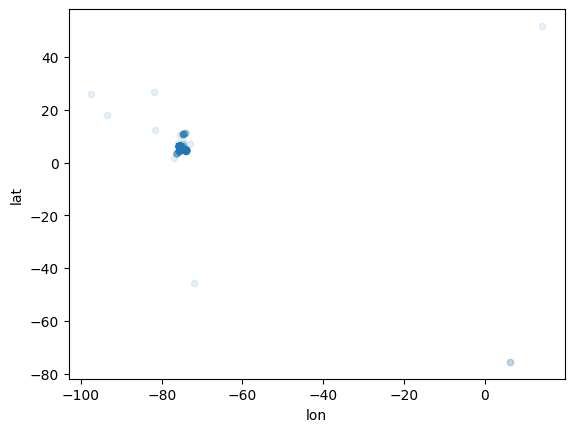

In [451]:
df_medellin_clean.plot(kind="scatter", x="lon", y="lat", alpha=0.1)

/var/folders/9r/f24wcwsd5lq1y7gwp439s8tm0000gn/T/ipykernel_84927/1320516810.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


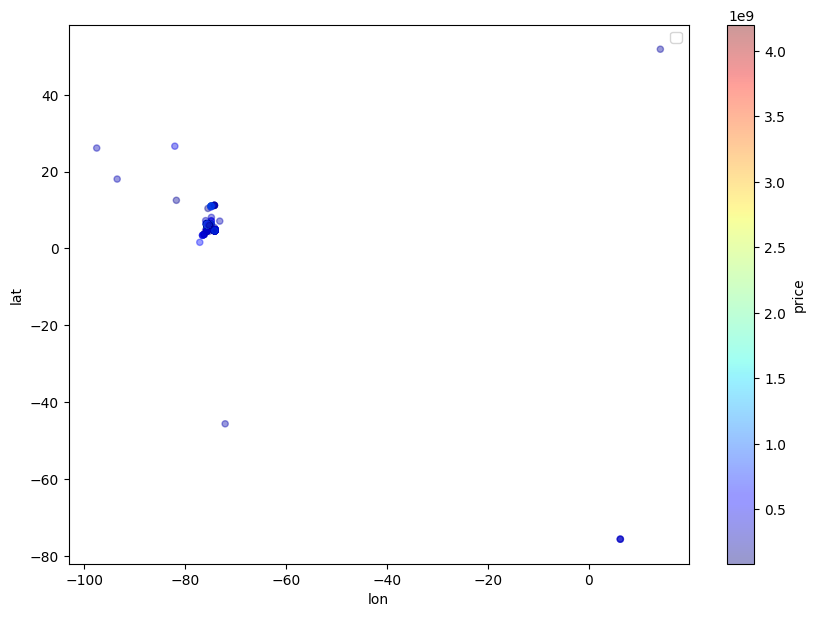

In [452]:
df_medellin_clean.plot(
    kind="scatter",
    x="lon",
    y="lat",
    alpha=0.4,
    figsize=(10, 7),
    c="price",
    cmap=plt.get_cmap("jet"),
    colorbar=True,
)
plt.legend()

## Buscando correlaciones

In [453]:
corr_matrix = df_medellin_clean.corr(numeric_only=True)
corr_matrix["price"].sort_values(ascending=False)

price              1.000000
bathrooms          0.674766
rooms              0.353544
bedrooms           0.259638
surface_total      0.111768
surface_covered    0.076278
lon                0.001399
lat               -0.008004
Name: price, dtype: float64

Vemos que las variables más correlacionadas son número de baños y area total:

array([[<Axes: xlabel='price', ylabel='price'>,
        <Axes: xlabel='bathrooms', ylabel='price'>,
        <Axes: xlabel='surface_total', ylabel='price'>,
        <Axes: xlabel='rooms', ylabel='price'>],
       [<Axes: xlabel='price', ylabel='bathrooms'>,
        <Axes: xlabel='bathrooms', ylabel='bathrooms'>,
        <Axes: xlabel='surface_total', ylabel='bathrooms'>,
        <Axes: xlabel='rooms', ylabel='bathrooms'>],
       [<Axes: xlabel='price', ylabel='surface_total'>,
        <Axes: xlabel='bathrooms', ylabel='surface_total'>,
        <Axes: xlabel='surface_total', ylabel='surface_total'>,
        <Axes: xlabel='rooms', ylabel='surface_total'>],
       [<Axes: xlabel='price', ylabel='rooms'>,
        <Axes: xlabel='bathrooms', ylabel='rooms'>,
        <Axes: xlabel='surface_total', ylabel='rooms'>,
        <Axes: xlabel='rooms', ylabel='rooms'>]], dtype=object)

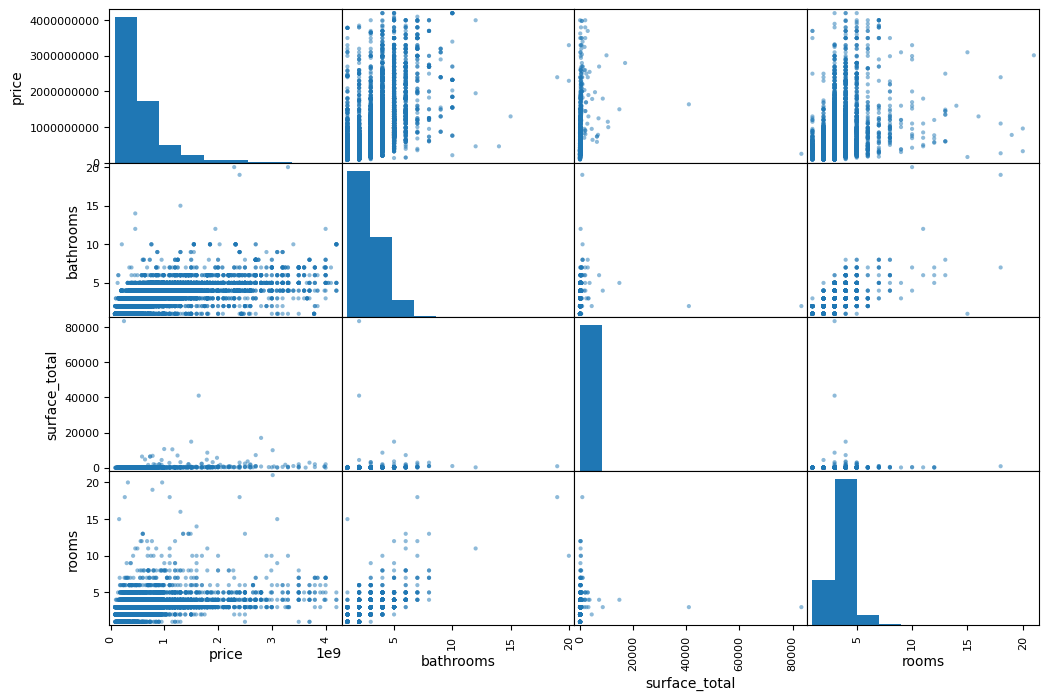

In [454]:
from pandas.plotting import scatter_matrix

attributes = [
    "price",
    "bathrooms",
    "surface_total",
    "rooms",
]
scatter_matrix(df_medellin_clean[attributes], figsize=(12, 8))

Veamos la gráfica de la variable más correlacionada por ahora:

<Axes: title={'center': 'Variable con mayor correlación'}, xlabel='bathrooms', ylabel='price'>

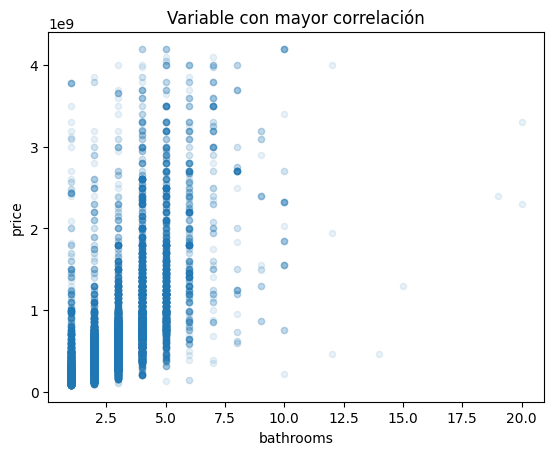

In [455]:
df_medellin_clean.plot(kind="scatter", x="bathrooms", y="price", alpha=0.1, title="Variable con mayor correlación")

Este análisis es para las variables númericas. Con las variables categoricas podemos hacer un histograma de frecuencias para ver que tanto se repite cada categoria

In [456]:
# Graficamos los 10 barrios más frecuentes para que sea legible
neighborhood_freq = df_medellin_clean["neighborhood"].fillna("Sin dato").value_counts().head(10).sort_values()
property_type_freq = df_medellin_clean["property_type"].fillna("Sin dato").value_counts()

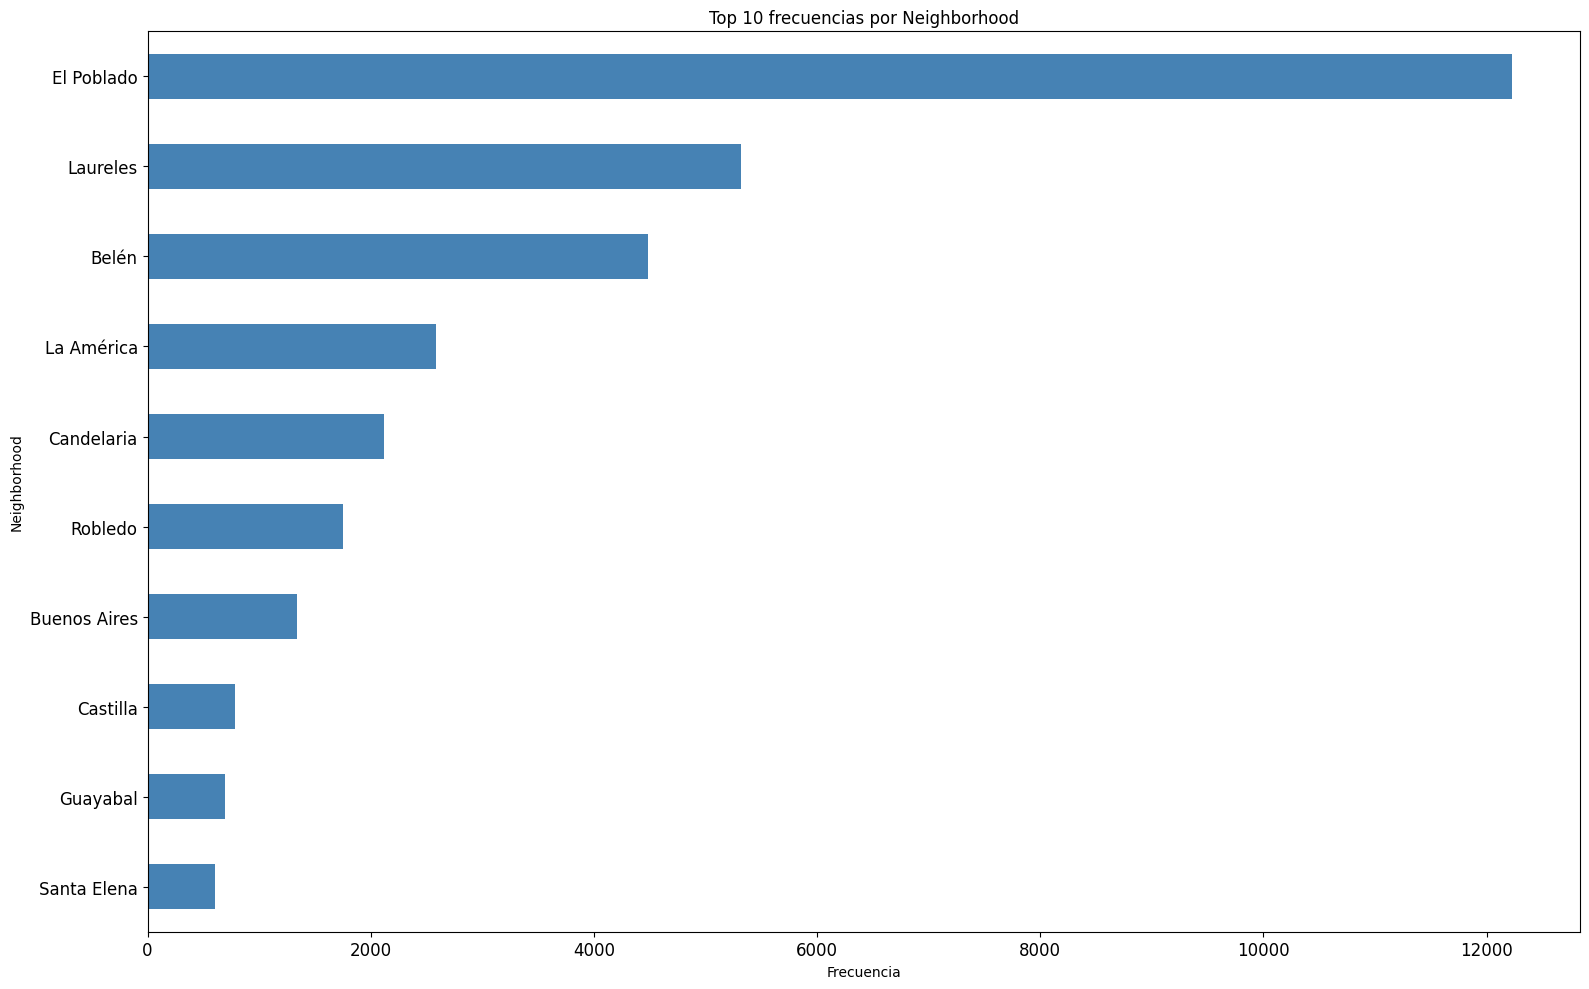

In [457]:
plt.figure(figsize=(16, 10))

neighborhood_freq.plot(
    kind="barh",
    color="steelblue",
    title="Top 10 frecuencias por Neighborhood",
)
plt.xlabel("Frecuencia")
plt.ylabel("Neighborhood")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

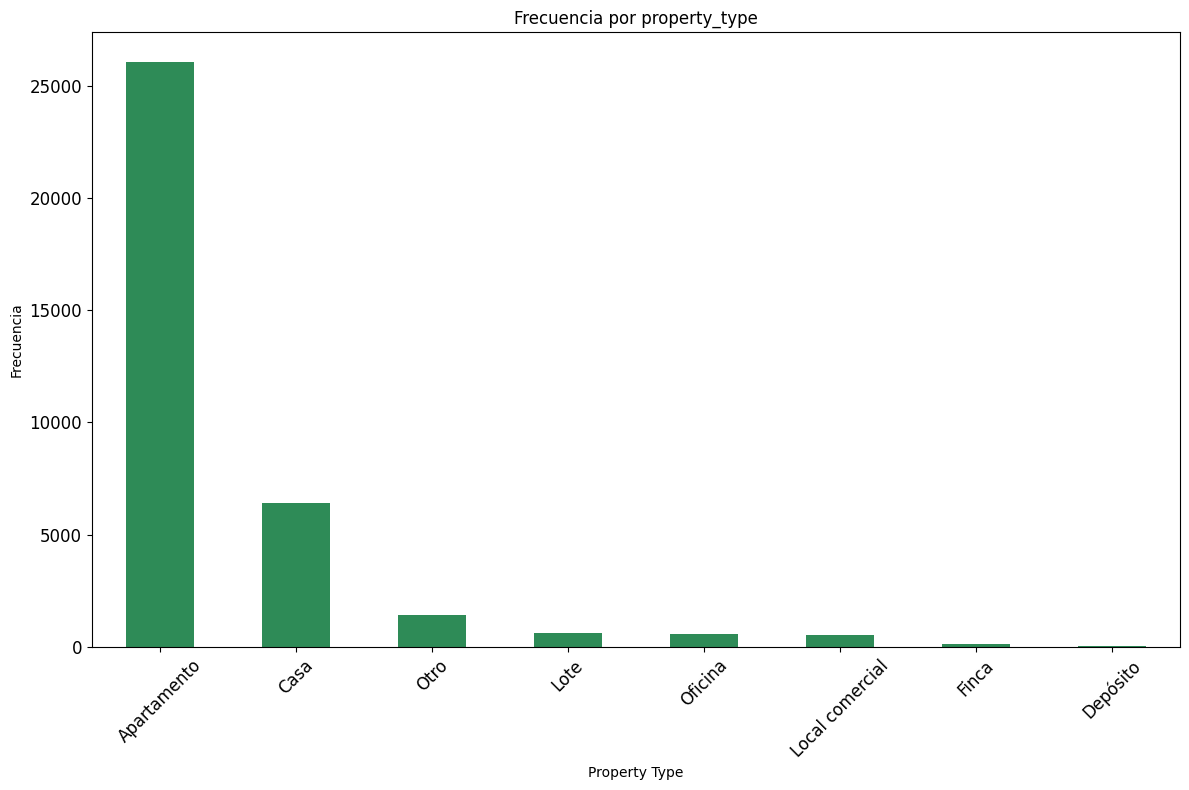

In [458]:
plt.figure(figsize=(12, 8))

property_type_freq.plot(
    kind="bar",
    color="seagreen",
    title="Frecuencia por property_type",
)
plt.xlabel("Property Type")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

# Entrenamiento

Separamos los datos que vamos a utilizar para el entrenamiento y los que vamos a usar para prueba. Una buena práctica es no manipular los datos de prueba hasta el final de nuestro proceso, cuando ya tengamos los modelos finales y vayamos a hacer la validación final, así que seguiremos esta recomendación.

In [459]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df_medellin_clean, test_size=0.3, random_state=42)

In [460]:
train_set.head()

,lat,lon,neighborhood,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,property_type
28776,6.212009,-75.559011,El Poblado,NaN,NaN,2.0,NaN,NaN,1.800000e+09,Oficina
4073,6.210000,-75.558000,El Poblado,NaN,3.0,4.0,NaN,NaN,7.100000e+08,Apartamento
10705,6.276607,-75.559693,Aranjuez,NaN,NaN,2.0,NaN,NaN,1.870000e+08,Casa
34244,6.282000,-75.561000,Aranjuez,2.0,2.0,1.0,65.0,65.0,1.400000e+08,Apartamento
6740,6.188863,-75.561118,El Poblado,4.0,4.0,NaN,NaN,NaN,8.900000e+08,Apartamento


Separamos los datos de la variable objetivo, en este caso precio

In [461]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 25069 entries, 28776 to 16121
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   lat              25069 non-null  float64
 1   lon              25069 non-null  float64
 2   neighborhood     24649 non-null  str    
 3   rooms            8247 non-null   float64
 4   bedrooms         13371 non-null  float64
 5   bathrooms        17134 non-null  float64
 6   surface_total    897 non-null    float64
 7   surface_covered  948 non-null    float64
 8   price            25069 non-null  float64
 9   property_type    25069 non-null  str    
dtypes: float64(8), str(2)
memory usage: 2.1 MB


In [462]:
house_data = train_set.drop(columns=["price"])
target = train_set["price"]

Usamos SimpleImputer para llenar los valores NaN de las variables numéricas, además, creamos un pipeline que se puede reutilizar en el momento de la evaluación. Adicionalmente, hacemos estandarización en los datos para evitar problemas con outliers y tener los datos escalados para el modelo. Esto para las variables numéricas:

In [463]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


house_num_features = house_data.drop(["neighborhood", "property_type"], axis=1)

num_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("std_scaler", StandardScaler()),
    ]
)

Ahora procesamos las variables categóricas, en este caso tenemos property_type y neighborhood. Para ambas haremos OneHotEncoder ya que no son muchas las categorías disponibles

In [464]:
house_data["neighborhood"] = house_data["neighborhood"].fillna("Unknown")

In [465]:
house_data

,lat,lon,neighborhood,rooms,bedrooms,bathrooms,surface_total,surface_covered,property_type
28776,6.212009,-75.559011,El Poblado,NaN,NaN,2.0,NaN,NaN,Oficina
4073,6.210000,-75.558000,El Poblado,NaN,3.0,4.0,NaN,NaN,Apartamento
10705,6.276607,-75.559693,Aranjuez,NaN,NaN,2.0,NaN,NaN,Casa
34244,6.282000,-75.561000,Aranjuez,2.0,2.0,1.0,65.0,65.0,Apartamento
6740,6.188863,-75.561118,El Poblado,4.0,4.0,NaN,NaN,NaN,Apartamento
...,...,...,...,...,...,...,...,...,...
17195,6.183168,-75.568113,El Poblado,NaN,NaN,6.0,NaN,NaN,Casa
6378,6.215963,-75.606627,Altavista,3.0,3.0,NaN,NaN,NaN,Apartamento
11499,6.225233,-75.565447,Candelaria,3.0,3.0,NaN,NaN,NaN,Apartamento
895,6.237220,-75.588056,Belén,4.0,4.0,NaN,NaN,NaN,Apartamento


In [466]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

num_attribs = list(house_num_features)
cat_attribs = ["neighborhood", "property_type"]

full_pipeline = ColumnTransformer(
    [
        ("num", num_pipeline, num_attribs),
        ("cat", OneHotEncoder(), cat_attribs),
    ]
)
housing_prepared = full_pipeline.fit_transform(house_data)

Una vez preparado el dataset de entrenamiento, podemos proceder a evaluar los modelos.

## Random Forest


In [467]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Training
forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared, target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### Resultados

In [468]:
predicted_price = forest_reg.predict(housing_prepared)

random_forest_mbe = mean_absolute_error(target, predicted_price)
random_forest_mse = mean_squared_error(target, predicted_price)
random_forest_rmse = np.sqrt(random_forest_mse)
random_forest_r2s = r2_score(target, predicted_price)

print("MAE:", random_forest_mbe)
print("MSE:", random_forest_mse)
print("RMSE:", random_forest_rmse)
print("R2_score:", random_forest_r2s)

MAE: 68563188.93791273
MSE: 2.074540545956612e+16
RMSE: 144032654.14330918
R2_score: 0.9332241235048951


**Usando cross-validation**

In [469]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    forest_reg,
    housing_prepared,
    target,
    scoring="neg_mean_squared_error",
    cv=10,
)
random_forest_rmse_scores = np.sqrt(-scores)

In [470]:
def display_scores(scores):
    print("Puntajes:", scores)
    print("Media:", scores.mean())
    print("Desviación estándar:", scores.std())

display_scores(random_forest_rmse_scores)

Puntajes: [3.22143443e+08 2.95221104e+08 3.11337325e+08 3.04718562e+08
 3.02173280e+08 2.83156449e+08 3.08494888e+08 3.02667365e+08
 3.16363336e+08 2.82114351e+08]
Media: 302839010.30783415
Desviación estándar: 12404561.29101466


Vemos un error típico de 306M con una variación aproximada de 18M. Tendremos que optimizar los parámetros para intentar mejorar el modelo.

## XGBoost

In [471]:
from xgboost import XGBRegressor

r_xgboost = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
r_xgboost.fit(housing_prepared, target)
r_xgboost.n_estimators

100

### Resultados

In [472]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

predicted_price = r_xgboost.predict(housing_prepared)

xgboost_mbe = mean_absolute_error(target, predicted_price)
xgboost_mse = mean_squared_error(target, predicted_price)
xgboost_rmse = np.sqrt(xgboost_mse)
xgboost_r2s = r2_score(target, predicted_price)

print("MAE:", xgboost_mbe)
print("MSE:", xgboost_mse)
print("RMSE:", xgboost_rmse)
print("R2_score:", xgboost_r2s)

MAE: 205620989.57832384
MSE: 1.276192861334072e+17
RMSE: 357238416.3740053
R2_score: 0.5892155636173293


## Optimizando los hiperparametros

A continuación se optimizan los hiperparámetros de Random Forest y XGBoost mediante GridSearchCV, que evalúa diferentes combinaciones y conserva la de mejor desempeño.

## Optimizando para Random Forest

In [473]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = [
    {
        'n_estimators': [50, 100],
        'max_depth': [None, 10],
        'max_features': ['sqrt', 0.5]
    }
]

random_forest_reg_op = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search_random_forest = GridSearchCV(random_forest_reg_op, param_grid, cv=3,
                                         scoring='neg_mean_squared_error',
                                         return_train_score=True,
                                         n_jobs=-1)

grid_search_random_forest.fit(housing_prepared, target)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'max_depth': [None, 10], 'max_features': ['sqrt', 0.5], 'n_estimators': [50, 100]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is disp

In [474]:
grid_search_random_forest.best_params_

{'max_depth': None, 'max_features': 0.5, 'n_estimators': 100}

In [475]:
best_params_random_forest = pd.DataFrame(
    grid_search_random_forest.best_params_.items(),
    columns=["Hiperparámetro", "Mejor valor"]
)

best_params_random_forest

,Hiperparámetro,Mejor valor
0,max_depth,NaN
1,max_features,0.5
2,n_estimators,100.0


Usando el mejor modelo encontrado:

In [476]:
best_random_forest = grid_search_random_forest.best_estimator_
best_random_forest
y_pred_best_random_forest = best_random_forest.predict(housing_prepared)

### Resultados

In [477]:
best_random_forest_mbe = mean_absolute_error(target, y_pred_best_random_forest)
best_random_forest_mse = mean_squared_error(target, y_pred_best_random_forest)
best_random_forest_rmse = np.sqrt(best_random_forest_mse)
best_random_forest_r2s = r2_score(target, y_pred_best_random_forest)

print("MAE:", best_random_forest_mbe)
print("MSE:", best_random_forest_mse)
print("RMSE:", best_random_forest_rmse)
print("R2_score:", best_random_forest_r2s)

MAE: 68044745.04686733
MSE: 2.0326646494301932e+16
RMSE: 142571548.68451816
R2_score: 0.9345720362752771


## Optimización XGBoost

In [478]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

param_grid = [
    {
        'n_estimators': [50, 100, 200],
        'max_depth': [2, 3, 4],
        'learning_rate': [0.03, 0.05, 0.1],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
]

xgboost_reg_op = XGBRegressor(random_state=42, objective='reg:squarederror', n_jobs=-1)

grid_search_xgboost = GridSearchCV(xgboost_reg_op, param_grid, cv=3,
                                   scoring='neg_mean_squared_error',
                                   return_train_score=True,
                                   n_jobs=-1)

grid_search_xgboost.fit(housing_prepared, target)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.03, 0.05, ...], 'max_depth': [2, 3, ...], 'n_estimators': [50, 100, ...], ...}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation 

In [479]:
grid_search_xgboost.best_params_

{'colsample_bytree': 1.0,
 'learning_rate': 0.1,
 'max_depth': 4,
 'n_estimators': 200,
 'subsample': 0.8}

Usando el mejor modelo encontrado:

In [480]:
best_xgboost = grid_search_xgboost.best_estimator_
best_xgboost
y_pred_best_xgboost = best_xgboost.predict(housing_prepared)

### Resultados

In [481]:
best_xgboost_mbe = mean_absolute_error(target, y_pred_best_xgboost)
best_xgboost_mse = mean_squared_error(target, y_pred_best_xgboost)
best_xgboost_rmse = np.sqrt(best_xgboost_mse)
best_xgboost_r2s = r2_score(target, y_pred_best_xgboost)

print("MAE:", best_xgboost_mbe)
print("MSE:", best_xgboost_mse)
print("RMSE:", best_xgboost_rmse)
print("R2_score:", best_xgboost_r2s)

MAE: 183441318.9790179
MSE: 1.0040852299349834e+17
RMSE: 316873039.23416764
R2_score: 0.6768023096228282


# Evaluación

Hasta ahora hemos entrenado y probado diferentes modelos en el data set de entrenamiento. Optimizamos los parámetros de los modelos usando Grid Search y tenemos ahora las mejores versiones de cada modelo. Vamos ahora a hacer la evaluación final usando el data set de test y comparar los resultados, tanto de los modelos base como de los optimizados

In [482]:
test_data = test_set.drop(columns=["price"])
test_data["neighborhood"] = test_data["neighborhood"].fillna("Unknown")
test_target = test_set["price"]

test_prepared = full_pipeline.transform(test_data)

In [483]:
test_data.info()

<class 'pandas.DataFrame'>
Index: 10745 entries, 32240 to 35826
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   lat              10745 non-null  float64
 1   lon              10745 non-null  float64
 2   neighborhood     10745 non-null  str    
 3   rooms            3453 non-null   float64
 4   bedrooms         5635 non-null   float64
 5   bathrooms        7434 non-null   float64
 6   surface_total    378 non-null    float64
 7   surface_covered  410 non-null    float64
 8   property_type    10745 non-null  str    
dtypes: float64(7), str(2)
memory usage: 839.5 KB


## Modelos base

### Random Forest base

In [484]:
y_pred_test_random_forest = forest_reg.predict(test_prepared)

test_random_forest_mbe = mean_absolute_error(test_target, y_pred_test_random_forest)
test_random_forest_mse = mean_squared_error(test_target, y_pred_test_random_forest)
test_random_forest_rmse = np.sqrt(test_random_forest_mse)
test_random_forest_r2s = r2_score(test_target, y_pred_test_random_forest)

print("MAE:", test_random_forest_mbe)
print("MSE:", test_random_forest_mse)
print("RMSE:", test_random_forest_rmse)
print("R2_score:", test_random_forest_r2s)

MAE: 143951413.95511243
MSE: 8.832889317375563e+16
RMSE: 297201771.8213598
R2_score: 0.7083497469917105


### XGBoost base

In [485]:
y_pred_test_xgboost = r_xgboost.predict(test_prepared)

test_xgboost_mbe = mean_absolute_error(test_target, y_pred_test_xgboost)
test_xgboost_mse = mean_squared_error(test_target, y_pred_test_xgboost)
test_xgboost_rmse = np.sqrt(test_xgboost_mse)
test_xgboost_r2s = r2_score(test_target, y_pred_test_xgboost)

print("MAE:", test_xgboost_mbe)
print("MSE:", test_xgboost_mse)
print("RMSE:", test_xgboost_rmse)
print("R2_score:", test_xgboost_r2s)

MAE: 212393905.96798512
MSE: 1.3744835109577216e+17
RMSE: 370740274.4452943
R2_score: 0.5461638323283688


## Modelos optimizados

### Random Forest optimizado

In [486]:
y_pred_test_best_random_forest = best_random_forest.predict(test_prepared)

test_best_random_forest_mbe = mean_absolute_error(test_target, y_pred_test_best_random_forest)
test_best_random_forest_mse = mean_squared_error(test_target, y_pred_test_best_random_forest)
test_best_random_forest_rmse = np.sqrt(test_best_random_forest_mse)
test_best_random_forest_r2s = r2_score(test_target, y_pred_test_best_random_forest)

print("MAE:", test_best_random_forest_mbe)
print("MSE:", test_best_random_forest_mse)
print("RMSE:", test_best_random_forest_rmse)
print("R2_score:", test_best_random_forest_r2s)

MAE: 143161927.8771472
MSE: 8.656130737223323e+16
RMSE: 294213030.5955758
R2_score: 0.7141860801292012


### XGBoost optimizado

In [487]:
y_pred_test_best_xgboost = best_xgboost.predict(test_prepared)

test_best_xgboost_mbe = mean_absolute_error(test_target, y_pred_test_best_xgboost)
test_best_xgboost_mse = mean_squared_error(test_target, y_pred_test_best_xgboost)
test_best_xgboost_rmse = np.sqrt(test_best_xgboost_mse)
test_best_xgboost_r2s = r2_score(test_target, y_pred_test_best_xgboost)

print("MAE:", test_best_xgboost_mbe)
print("MSE:", test_best_xgboost_mse)
print("RMSE:", test_best_xgboost_rmse)
print("R2_score:", test_best_xgboost_r2s)

MAE: 198111760.7493718
MSE: 1.2169538596600944e+17
RMSE: 348848657.68124926
R2_score: 0.5981780272383888


## Resultados

A continuación vamos a analizar los resultados de nuestros modelos. Algo que podemos analizar es la importancia que tiene cada característica para el modelo, usando el modelo optimizado de Random Forest para esto:

Top 10 características más importantes:
                  Feature  Importance
                bathrooms    0.256779
                      lat    0.212653
                      lon    0.209741
  neighborhood_El Poblado    0.078342
property_type_Apartamento    0.038842
                 bedrooms    0.035752
                    rooms    0.028581
       property_type_Casa    0.023746
 neighborhood_Santa Elena    0.021697
       property_type_Otro    0.013290


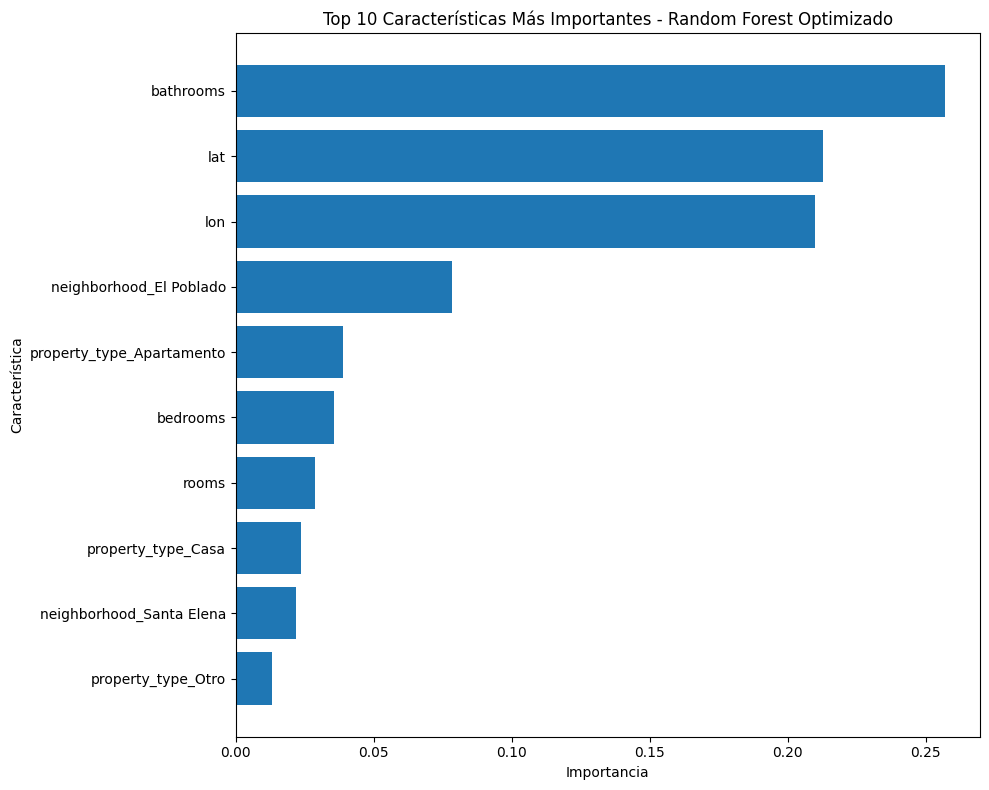


Importancia total de variables numéricas: 0.7667
Importancia total de variables categóricas: 0.2333


In [488]:
num_attribs = ['lat', 'lon', 'rooms', 'bedrooms', 'bathrooms', 'surface_total', 'surface_covered']


cat_encoder = full_pipeline.named_transformers_['cat']
cat_feature_names = []
for i, cat in enumerate(['neighborhood', 'property_type']):
    categories = cat_encoder.categories_[i]
    cat_feature_names.extend([f"{cat}_{category}" for category in categories])

all_feature_names = num_attribs + cat_feature_names

feature_importances = best_random_forest.feature_importances_


importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("Top 10 características más importantes:")
print(importance_df.head(10).to_string(index=False))


plt.figure(figsize=(10, 8))
top_features = importance_df.head(10)
plt.barh(range(len(top_features)), top_features['Importance'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.title('Top 10 Características Más Importantes - Random Forest Optimizado')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

num_importance = importance_df[importance_df['Feature'].isin(num_attribs)]['Importance'].sum()
cat_importance = importance_df[~importance_df['Feature'].isin(num_attribs)]['Importance'].sum()

print(f"\nImportancia total de variables numéricas: {num_importance:.4f}")
print(f"Importancia total de variables categóricas: {cat_importance:.4f}")


Del resultado anterior, podemos confirmar que el número de baños es la caracteristica más importante y relacionada con el precio. Adicionalmente, vemos que la ubicación también es importante. Esto era algo que no mostraba la correlación. Incluso vemos que el hecho de que un inmueble esté ubicado en el poblado tiene una gran importancia en relación al precio.

Ahora vamos a comparar los resultados de todos modelos:

In [489]:
test_model_comparison_values = pd.DataFrame(
    {
        "Random Forest base": [test_random_forest_mbe, test_random_forest_mse, test_random_forest_rmse, test_random_forest_r2s],
        "Random Forest optimizado": [test_best_random_forest_mbe, test_best_random_forest_mse, test_best_random_forest_rmse, test_best_random_forest_r2s],
        "XGBoost base": [test_xgboost_mbe, test_xgboost_mse, test_xgboost_rmse, test_xgboost_r2s],
        "XGBoost optimizado": [test_best_xgboost_mbe, test_best_xgboost_mse, test_best_xgboost_rmse, test_best_xgboost_r2s],
    },
    index=["MAE", "MSE", "RMSE", "R2_score"],
)

metric_formatters = {
    "MAE": lambda value: f"{value:.3f}",
    "MSE": lambda value: f"{value:.3e}",
    "RMSE": lambda value: f"{value:.3f}",
    "R2_score": lambda value: f"{value:.3f}",
}

test_model_comparison = pd.DataFrame(
    {
        model_name: [
            metric_formatters[metric](test_model_comparison_values.loc[metric, model_name])
            for metric in test_model_comparison_values.index
        ]
        for model_name in test_model_comparison_values.columns
    }
)

test_model_comparison.insert(0, "Métrica", test_model_comparison_values.index)

test_model_comparison

,Métrica,Random Forest base,Random Forest optimizado,XGBoost base,XGBoost optimizado
0,MAE,143951413.955,143161927.877,212393905.968,198111760.749
1,MSE,8.833e+16,8.656e+16,1.374e+17,1.217e+17
2,RMSE,297201771.821,294213030.596,370740274.445,348848657.681
3,R2_score,0.708,0.714,0.546,0.598


# Análisis espacial

En esta sección se prepara el conjunto de datos para incorporar su componente espacial. Primero se crea un `GeoDataFrame` a partir de la longitud y la latitud; luego se proyectan las geometrías a un sistema de coordenadas métrico y, finalmente, se transforma el precio con el logaritmo natural para reducir su asimetría.

In [490]:
%pip install geopandas libpysal esda splot spreg


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Construcción del GeoDataFrame

Las columnas `lon` y `lat` representan coordenadas geográficas en grados. A partir de ellas se crea una geometría de puntos con el sistema de referencia WGS 84 (`EPSG:4326`).

In [491]:
import geopandas as gpd

medellin_gdf = gpd.GeoDataFrame(
    df_medellin_clean.copy(),
    geometry=gpd.points_from_xy(
        df_medellin_clean["lon"],
        df_medellin_clean["lat"],
    ),
    crs="EPSG:4326",
)

print(f"Registros en el GeoDataFrame: {len(medellin_gdf)}")
print(f"Sistema de coordenadas inicial: {medellin_gdf.crs}")
medellin_gdf.head()

Registros en el GeoDataFrame: 35814
Sistema de coordenadas inicial: EPSG:4326


,lat,lon,neighborhood,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,property_type,geometry
0,6.297802,-75.577835,Doce de Octubre,5.0,5.0,NaN,NaN,NaN,3.100000e+08,Casa,POINT (-75.57784 6.2978)
1,6.307000,-75.579002,Doce de Octubre,NaN,NaN,NaN,NaN,NaN,1.500000e+08,Casa,POINT (-75.579 6.307)
2,6.201145,-75.565205,El Poblado,3.0,3.0,NaN,NaN,NaN,1.250000e+09,Casa,POINT (-75.56521 6.20115)
3,6.256467,-75.557640,Villa Hermosa,6.0,6.0,NaN,NaN,NaN,1.800000e+08,Casa,POINT (-75.55764 6.25647)
5,6.307757,-75.560560,Castilla,NaN,NaN,1.0,NaN,NaN,1.720000e+08,Casa,POINT (-75.56056 6.30776)


## Proyección a coordenadas métricas

Las distancias no deben calcularse directamente con latitud y longitud porque están expresadas en grados. Se utiliza MAGNA-SIRGAS / Origen-Nacional (`EPSG:9377`), cuyas unidades son metros, para que las distancias y las relaciones de vecindad posteriores tengan una interpretación espacial adecuada.

In [492]:
medellin_gdf = medellin_gdf.to_crs(epsg=9377)

print(f"Sistema de coordenadas proyectado: {medellin_gdf.crs}")
print(f"Unidad de medida: {medellin_gdf.crs.axis_info[0].unit_name}")
medellin_gdf[["lat", "lon", "geometry"]].head()

Sistema de coordenadas proyectado: EPSG:9377
Unidad de medida: metre


,lat,lon,geometry
0,6.297802,-75.577835,POINT (4714890.658 2254599.315)
1,6.307000,-75.579002,POINT (4714766.513 2255617.365)
2,6.201145,-75.565205,POINT (4716236.297 2243901.455)
3,6.256467,-75.557640,POINT (4717103.421 2250016.376)
5,6.307757,-75.560560,POINT (4716807.949 2255691.04)


## Transformación logarítmica del precio

El precio original se conserva y se crea `log_price` como una variable adicional. La transformación reduce la influencia de los inmuebles extremadamente costosos y permite analizar con mayor estabilidad los patrones espaciales del precio.

In [493]:
import numpy as np

medellin_gdf["log_price"] = np.log(medellin_gdf["price"])

print("Resumen del precio original y su transformación logarítmica:")
medellin_gdf[["price", "log_price"]].describe()

Resumen del precio original y su transformación logarítmica:


,price,log_price
count,3.581400e+04,35814.000000
mean,5.948796e+08,19.909397
std,5.552808e+08,0.737620
min,8.200000e+07,18.222230
25%,2.650000e+08,19.395240
50%,4.200000e+08,19.855765
75%,7.000000e+08,20.366591
max,4.200000e+09,22.158350


## Matrices de pesos espaciales KNN

Una matriz de pesos espaciales representa cuáles observaciones se consideran vecinas. Como los inmuebles son puntos, se utiliza el criterio de los vecinos más cercanos (*K-Nearest Neighbors* o KNN). Se comparan matrices con 5, 10 y 20 vecinos para verificar si el resultado depende de una única definición de vecindad.

Cada matriz se estandariza por filas. De esta forma, los pesos asignados a los vecinos de cada inmueble suman uno y su rezago espacial puede interpretarse como un promedio de los valores vecinos.

In [494]:
from libpysal.weights import KNN

medellin_gdf = medellin_gdf.reset_index(drop=True)
neighbor_counts = [5, 10, 20]
spatial_weights = {}

for neighbor_count in neighbor_counts:
    weights = KNN.from_dataframe(
        medellin_gdf,
        k=neighbor_count,
        use_index=True,
    )
    weights.transform = "R"
    spatial_weights[neighbor_count] = weights

print("Matrices de pesos espaciales construidas:")
for neighbor_count, weights in spatial_weights.items():
    print(
        f"KNN k={neighbor_count}: "
        f"{weights.n} observaciones y "
        f"{sum(len(neighbors) for neighbors in weights.neighbors.values())} conexiones"
    )

/opt/anaconda3/envs/ml_tf/lib/python3.13/site-packages/libpysal/weights/distance.py:164: UserWarning: The weights matrix is not fully connected: 
 There are 434 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
/opt/anaconda3/envs/ml_tf/lib/python3.13/site-packages/libpysal/weights/distance.py:164: UserWarning: The weights matrix is not fully connected: 
 There are 18 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


Matrices de pesos espaciales construidas:
KNN k=5: 35814 observaciones y 179070 conexiones
KNN k=10: 35814 observaciones y 358140 conexiones
KNN k=20: 35814 observaciones y 716280 conexiones


## Autocorrelación espacial global

El I de Moran compara el valor de cada inmueble con los valores de sus vecinos. Un valor positivo y estadísticamente significativo indica que precios similares tienden a agruparse; un valor cercano a cero es compatible con aleatoriedad espacial, y un valor negativo indica proximidad entre valores diferentes.

La significancia se evalúa mediante 999 permutaciones aleatorias. Se calcula el estadístico tanto para el precio original como para su transformación logarítmica.

In [495]:
from esda import Moran

np.random.seed(42)
moran_statistics = {}
moran_rows = []

for neighbor_count, weights in spatial_weights.items():
    for variable in ["price", "log_price"]:
        moran = Moran(
            medellin_gdf[variable].to_numpy(),
            weights,
            permutations=999,
        )
        moran_statistics[(neighbor_count, variable)] = moran
        moran_rows.append(
            {
                "Vecinos (k)": neighbor_count,
                "Variable": variable,
                "I de Moran": moran.I,
                "I esperado": moran.EI,
                "Valor p simulado": moran.p_sim,
                "Z simulado": moran.z_sim,
            }
        )

moran_results = pd.DataFrame(moran_rows)
moran_results.round(4)

,Vecinos (k),Variable,I de Moran,I esperado,Valor p simulado,Z simulado
0,5,price,0.5165,-0.0,0.001,181.9430
1,5,log_price,0.6506,-0.0,0.001,223.8030
2,10,price,0.4542,-0.0,0.001,226.5952
3,10,log_price,0.6000,-0.0,0.001,279.7823
4,20,price,0.4151,-0.0,0.001,277.5446
5,20,log_price,0.5671,-0.0,0.001,366.6010


### Comparación de la sensibilidad al número de vecinos

La siguiente figura permite comprobar si la magnitud y la dirección de la autocorrelación se mantienen al cambiar el número de vecinos. Resultados semejantes para los tres valores de (k) indican que la conclusión es robusta frente a esta decisión.

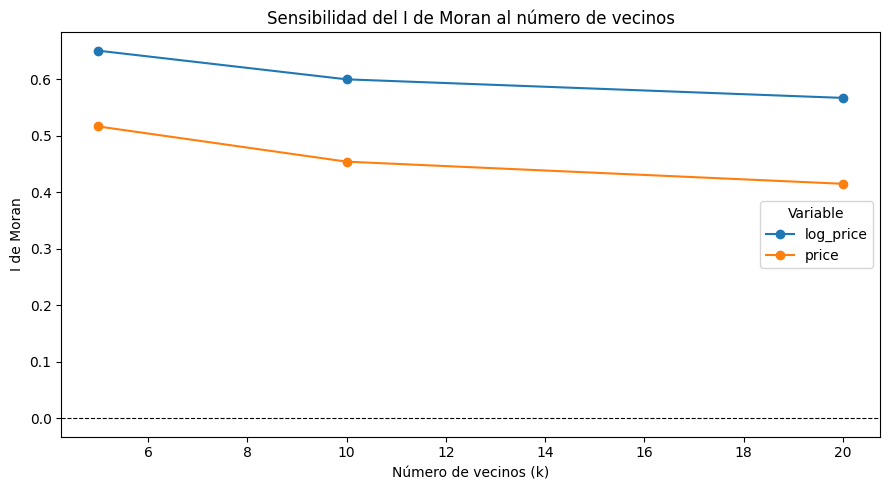

In [496]:
moran_comparison = moran_results.pivot(
    index="Vecinos (k)",
    columns="Variable",
    values="I de Moran",
)

ax = moran_comparison.plot(marker="o", figsize=(9, 5))
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Número de vecinos (k)")
ax.set_ylabel("I de Moran")
ax.set_title("Sensibilidad del I de Moran al número de vecinos")
ax.legend(title="Variable")
plt.tight_layout()
plt.show()

### Gráficos de Moran

Para visualizar el patrón se utiliza la matriz intermedia KNN con 10 vecinos. El eje horizontal muestra el precio estandarizado de cada inmueble y el vertical representa el rezago espacial, es decir, el comportamiento promedio de sus vecinos. Una pendiente positiva refleja agrupación de valores similares.

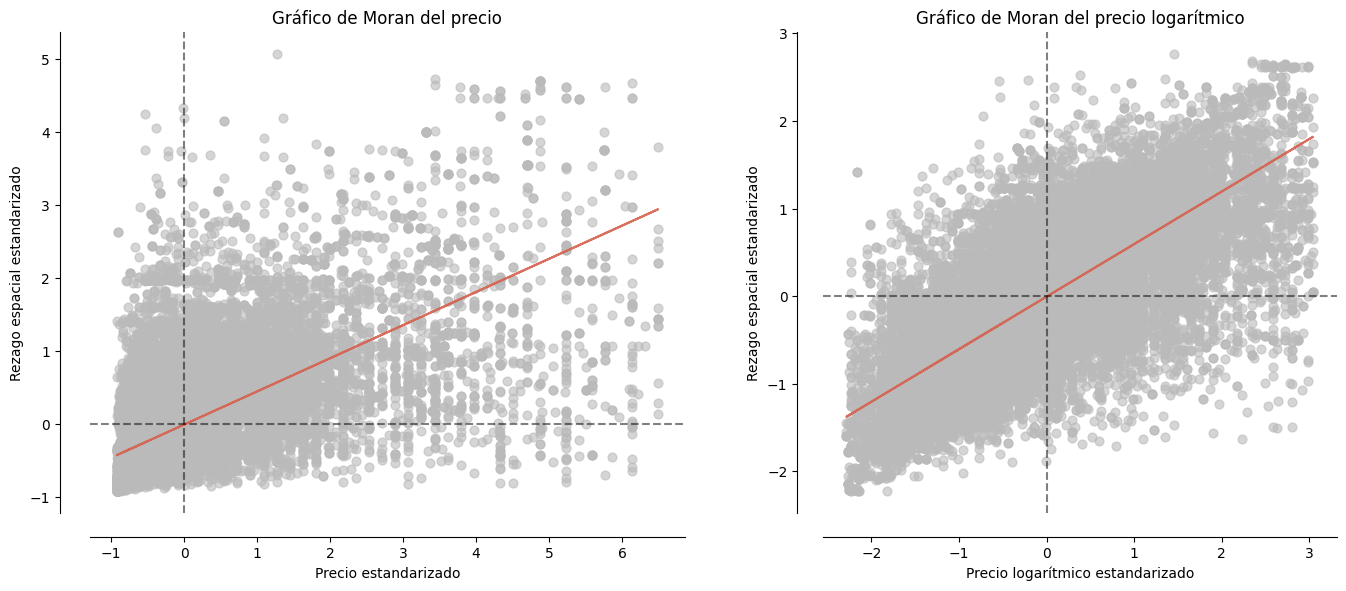

In [497]:
from splot.esda import moran_scatterplot

figure, axes = plt.subplots(1, 2, figsize=(14, 6))

moran_scatterplot(
    moran_statistics[(10, "price")],
    ax=axes[0],
    aspect_equal=True,
)
axes[0].set_title("Gráfico de Moran del precio")
axes[0].set_xlabel("Precio estandarizado")
axes[0].set_ylabel("Rezago espacial estandarizado")

moran_scatterplot(
    moran_statistics[(10, "log_price")],
    ax=axes[1],
    aspect_equal=True,
)
axes[1].set_title("Gráfico de Moran del precio logarítmico")
axes[1].set_xlabel("Precio logarítmico estandarizado")
axes[1].set_ylabel("Rezago espacial estandarizado")

plt.tight_layout()
plt.show()

### Lectura de la autocorrelación global y los gráficos de Moran

Los seis valores del I de Moran son positivos y tienen `p = 0.001`. Por tanto, se rechaza la hipótesis de aleatoriedad espacial: los inmuebles con precios altos tienden a localizarse cerca de otros inmuebles costosos, mientras que los precios bajos también tienden a agruparse. Este resultado se mantiene tanto para `price` como para `log_price` y para las tres matrices KNN.

El análisis de sensibilidad muestra que el I de Moran disminuye cuando el número de vecinos aumenta. Para `log_price` pasa de 0.6506 con 5 vecinos a 0.6000 con 10 y 0.5671 con 20; para `price` pasa de 0.5165 a 0.4542 y 0.4151. Esto indica que la asociación es principalmente local: es más fuerte entre las viviendas más próximas y se diluye al incorporar inmuebles progresivamente más lejanos. Como el signo y la significancia no cambian, la conclusión es robusta frente a la selección de (k).

En los gráficos de Moran se observa una pendiente positiva. La concentración predominante en los cuadrantes Alto-Alto y Bajo-Bajo confirma que valores similares comparten vecindario. El gráfico del precio original presenta mayor dispersión por la influencia de los inmuebles extremadamente costosos. Después de aplicar el logaritmo, esos valores pierden influencia y el patrón espacial general se vuelve más claro; por eso el I de Moran de `log_price` es mayor en las tres matrices.

Se selecciona KNN con 20 vecinos para los diagnósticos y modelos posteriores. Aunque produce un Moran ligeramente menor, mantiene una asociación fuerte y significativa y conecta todas las observaciones en una sola red espacial, evitando los componentes desconectados encontrados con 5 y 10 vecinos.

## Autocorrelación espacial de los residuos de Random Forest

El I de Moran del precio confirma que existe un patrón espacial, pero no permite saber si Random Forest ya consiguió explicarlo. Para evaluarlo se calculan los residuos del modelo optimizado sobre el conjunto de prueba. Un residuo positivo indica que el modelo subestimó el precio y uno negativo indica que lo sobreestimó.

La matriz espacial se reconstruye utilizando solamente las observaciones de prueba para evitar relacionarlas con datos empleados durante el entrenamiento.

In [498]:
test_spatial_data = test_set.loc[
    test_target.index,
    ["lat", "lon", "price"],
].copy()
test_spatial_data["random_forest_residual"] = (
    test_target.to_numpy() - y_pred_test_best_random_forest
)

test_gdf = gpd.GeoDataFrame(
    test_spatial_data,
    geometry=gpd.points_from_xy(
        test_spatial_data["lon"],
        test_spatial_data["lat"],
    ),
    crs="EPSG:4326",
).to_crs(epsg=9377)
test_gdf = test_gdf.reset_index(drop=True)

test_weights = KNN.from_dataframe(
    test_gdf,
    k=20,
    use_index=True,
)
test_weights.transform = "R"

print(f"Observaciones de prueba: {len(test_gdf)}")
print(f"Componentes de la matriz KNN: {test_weights.n_components}")

Observaciones de prueba: 10745
Componentes de la matriz KNN: 1


In [499]:
np.random.seed(42)
random_forest_residual_moran = Moran(
    test_gdf["random_forest_residual"].to_numpy(),
    test_weights,
    permutations=999,
)

random_forest_residual_results = pd.DataFrame(
    {
        "Indicador": [
            "I de Moran",
            "I esperado",
            "Valor p simulado",
            "Z simulado",
        ],
        "Resultado": [
            random_forest_residual_moran.I,
            random_forest_residual_moran.EI,
            random_forest_residual_moran.p_sim,
            random_forest_residual_moran.z_sim,
        ],
    }
)
random_forest_residual_results.round(4)

,Indicador,Resultado
0,I de Moran,0.0222
1,I esperado,-0.0001
2,Valor p simulado,0.0010
3,Z simulado,7.9418


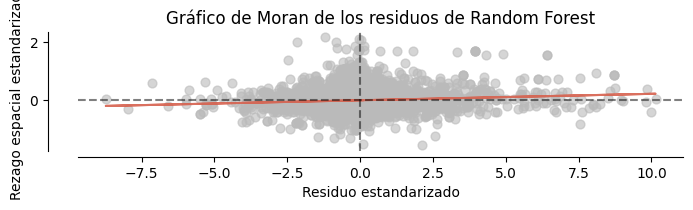

In [500]:
figure, axis = plt.subplots(figsize=(7, 6))
moran_scatterplot(
    random_forest_residual_moran,
    ax=axis,
    aspect_equal=True,
)
axis.set_title("Gráfico de Moran de los residuos de Random Forest")
axis.set_xlabel("Residuo estandarizado")
axis.set_ylabel("Rezago espacial estandarizado")
plt.tight_layout()
plt.show()

### Interpretación de los residuos de Random Forest

Los residuos de Random Forest presentan un I de Moran de 0.0222 con `p = 0.001`. El resultado es estadísticamente significativo, pero su magnitud es muy baja porque el estadístico se encuentra cerca de cero. Esto indica que queda una agrupación espacial leve de los errores: viviendas cercanas todavía pueden ser subestimadas o sobreestimadas de forma similar, aunque el patrón es débil.

La autocorrelación residual es mucho menor que la observada en el precio original y en `log_price`. Por tanto, Random Forest captura casi toda la estructura espacial mediante latitud, longitud, barrio y relaciones no lineales entre las variables. El valor p pequeño se explica en parte por el tamaño del conjunto de prueba, que contiene 10.745 observaciones y permite detectar asociaciones incluso muy débiles. En consecuencia, debe evaluarse conjuntamente la significancia y la magnitud del I de Moran: existe dependencia residual, pero su importancia práctica es reducida.

## Regresión OLS hedónica para diagnóstico espacial

Se ajusta una regresión OLS con el precio logarítmico como variable dependiente. Esta regresión no busca reemplazar Random Forest; funciona como modelo global de referencia y permite aplicar los diagnósticos que orientan la elección entre un modelo de rezago espacial (SAR-Lag) y un modelo de error espacial (SEM).

Se utilizan habitaciones, dormitorios, baños, tipo de propiedad y barrio. `surface_total` y `surface_covered` se excluyen de esta especificación porque tienen un porcentaje extremo de valores faltantes. Las variables numéricas se imputan con la mediana y se estandarizan; las categóricas se imputan con la categoría más frecuente y se codifican mediante variables indicadoras.

In [501]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ols_numeric_features = ["rooms", "bedrooms", "bathrooms"]
ols_categorical_features = ["neighborhood", "property_type"]

ols_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
ols_categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

ols_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", ols_numeric_pipeline, ols_numeric_features),
        ("categorical", ols_categorical_pipeline, ols_categorical_features),
    ]
)

ols_features = ols_numeric_features + ols_categorical_features
ols_x = ols_preprocessor.fit_transform(medellin_gdf[ols_features]).astype(float)
ols_y = medellin_gdf["log_price"].to_numpy().reshape(-1, 1)
ols_feature_names = ols_preprocessor.get_feature_names_out().tolist()

print(f"Observaciones del modelo OLS: {ols_x.shape[0]}")
print(f"Variables explicativas después de la codificación: {ols_x.shape[1]}")

Observaciones del modelo OLS: 35814
Variables explicativas después de la codificación: 30


In [502]:
from spreg import OLS

ols_spatial_model = OLS(
    ols_y,
    ols_x,
    w=spatial_weights[20],
    spat_diag=True,
    moran=True,
    name_y="Precio logarítmico",
    name_x=ols_feature_names,
    name_w="KNN con 20 vecinos",
    name_ds="Viviendas de Medellín",
)

print(ols_spatial_model.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :Viviendas de Medellín
Weights matrix      :KNN con 20 vecinos
Dependent Variable  :Precio logarítmico                Number of Observations:       35814
Mean dependent var  :     19.9094                Number of Variables   :          31
S.D. dependent var  :      0.7376                Degrees of Freedom    :       35783
R-squared           :      0.5861
Adjusted R-squared  :      0.5857
Sum squared residual:     8065.08                F-statistic           :   1688.9577
Sigma-square        :       0.225                Prob(F-statistic)     :           0
S.E. of regression  :       0.475                Log likelihood        :  -24122.191
Sigma-square ML     :       0.225                Akaike info criterion :   48306.382
S.E of regression ML:      0.4745                Schwarz criterion     :   48569.4

### Diagnósticos espaciales del modelo OLS

El I de Moran de los residuos permite verificar si el OLS deja estructura espacial sin explicar. Las pruebas LM evalúan dos alternativas: LM-Lag busca dependencia en la variable dependiente y LM-Error busca dependencia en el término de error. Cuando ambas pruebas son significativas, sus versiones robustas ayudan a identificar el proceso dominante.

In [503]:
np.random.seed(42)
ols_residual_moran = Moran(
    ols_spatial_model.u.flatten(),
    spatial_weights[20],
    permutations=999,
)

ols_spatial_diagnostics = pd.DataFrame(
    [
        {
            "Diagnóstico": "I de Moran de los residuos",
            "Estadístico": ols_residual_moran.I,
            "Valor p": ols_residual_moran.p_sim,
        },
        {
            "Diagnóstico": "LM-Lag",
            "Estadístico": ols_spatial_model.lm_lag[0],
            "Valor p": ols_spatial_model.lm_lag[1],
        },
        {
            "Diagnóstico": "LM-Error",
            "Estadístico": ols_spatial_model.lm_error[0],
            "Valor p": ols_spatial_model.lm_error[1],
        },
        {
            "Diagnóstico": "LM-Lag robusto",
            "Estadístico": ols_spatial_model.rlm_lag[0],
            "Valor p": ols_spatial_model.rlm_lag[1],
        },
        {
            "Diagnóstico": "LM-Error robusto",
            "Estadístico": ols_spatial_model.rlm_error[0],
            "Valor p": ols_spatial_model.rlm_error[1],
        },
    ]
)
def format_analytical_p_value(value):
    return "< 0.001" if value < 0.001 else f"{value:.3f}"


ols_spatial_diagnostics_display = ols_spatial_diagnostics.copy()
ols_spatial_diagnostics_display["Valor p"] = (
    ols_spatial_diagnostics_display["Valor p"].map(format_analytical_p_value)
)
ols_spatial_diagnostics_display["Estadístico"] = (
    ols_spatial_diagnostics_display["Estadístico"].round(4)
)
ols_spatial_diagnostics_display

,Diagnóstico,Estadístico,Valor p
0,I de Moran de los residuos,0.2673,0.001
1,LM-Lag,20938.3866,< 0.001
2,LM-Error,30700.7292,< 0.001
3,LM-Lag robusto,1598.8389,< 0.001
4,LM-Error robusto,11361.1815,< 0.001


In [504]:
ols_model_metrics = pd.DataFrame(
    {
        "Métrica": ["R²", "R² ajustado", "AIC", "RMSE en escala logarítmica"],
        "Resultado": [
            ols_spatial_model.r2,
            ols_spatial_model.ar2,
            ols_spatial_model.aic,
            np.sqrt(
                mean_squared_error(
                    ols_y.flatten(),
                    ols_spatial_model.predy.flatten(),
                )
            ),
        ],
    }
)
ols_model_metrics.round(4)

,Métrica,Resultado
0,R²,0.5861
1,R² ajustado,0.5857
2,AIC,48306.3818
3,RMSE en escala logarítmica,0.4745


### Interpretación del diagnóstico OLS

El modelo OLS obtiene R² = 0.5861 y RMSE = 0.4745 en escala logarítmica. Explica una parte importante de la variación del precio, pero sus residuos presentan autocorrelación positiva (I de Moran = 0.2673; `p = 0.001`). Esto indica que OLS deja un patrón espacial considerable sin explicar.

LM-Lag y LM-Error, junto con sus versiones robustas, son significativos (`p < 0.001`). LM-Error robusto obtiene 11.361,18 y LM-Lag robusto 1.598,84. La evidencia es más fuerte para dependencia espacial en los errores, aunque ambas formas de dependencia están presentes. Por esta razón se justifica ajustar y comparar SEM y SAR-Lag.

Los residuos tampoco cumplen normalidad y homocedasticidad según Jarque-Bera, Breusch-Pagan y Koenker-Bassett. En consecuencia, OLS funciona como referencia, pero no representa adecuadamente toda la estructura estadística y espacial de los datos.

## Modelos de dependencia espacial

Las pruebas LM robustas fueron significativas tanto para dependencia en el error como para dependencia en la variable dependiente. Por esta razón se ajustan los dos modelos y se comparan empíricamente.

- **SEM:** representa la dependencia espacial mediante el término de error. Su parámetro λ indica la intensidad con la que factores espaciales no observados se relacionan entre viviendas vecinas.
- **SAR-Lag:** incorpora el rezago espacial de `log_price`. Su parámetro ρ representa la relación entre el precio de una vivienda y los precios de sus vecinas, después de controlar las características incluidas.

Se utilizan las implementaciones `GM_Error_Het` y `GM_Lag` presentadas en el capítulo de modelos SAR del libro. Estos estimadores GMM son apropiados para una muestra grande y el primero permite errores heterocedásticos.

### Modelo de error espacial (SEM)

In [505]:
import spreg

sem_model = spreg.GM_Error_Het(
    ols_y,
    ols_x,
    w=spatial_weights[20],
    name_y="Precio logarítmico",
    name_x=ols_feature_names,
    name_w="KNN con 20 vecinos",
    name_ds="Viviendas de Medellín",
)

print(sem_model.summary)

GM_Error_Het
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: GM SPATIALLY WEIGHTED LEAST SQUARES (HET)
------------------------------------------------------------------------------------
Data set            :Viviendas de Medellín
Weights matrix      :KNN con 20 vecinos
Dependent Variable  :Precio logarítmico                Number of Observations:       35814
Mean dependent var  :     19.9094                Number of Variables   :          31
S.D. dependent var  :      0.7376                Degrees of Freedom    :       35783
Pseudo R-squared    :      0.5783
N. of iterations    :           1                Step1c computed       :          No

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT        19.72455         0.03646       540.94833         0.0000

### Modelo de rezago espacial (SAR-Lag)

In [506]:
sar_lag_model = spreg.GM_Lag(
    ols_y,
    ols_x,
    w=spatial_weights[20],
    name_y="Precio logarítmico",
    name_x=ols_feature_names,
    name_w="KNN con 20 vecinos",
    name_ds="Viviendas de Medellín",
)

print(sar_lag_model.summary)

GM_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIAL TWO STAGE LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :Viviendas de Medellín
Weights matrix      :KNN con 20 vecinos
Dependent Variable  :Precio logarítmico                Number of Observations:       35814
Mean dependent var  :     19.9094                Number of Variables   :          32
S.D. dependent var  :      0.7376                Degrees of Freedom    :       35782
Pseudo R-squared    :      0.6749
Spatial Pseudo R-squared:  0.6029

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         9.88838         0.18373        53.82123         0.00000
      numeric__rooms         0.08323         0.00355        23.46

### Autocorrelación residual de los modelos espaciales

En SEM se analiza `e_filtered`, que representa el residuo después de retirar el componente espacial estimado. El residuo `u` no es adecuado para este diagnóstico porque todavía contiene la dependencia modelada mediante λ. En SAR-Lag se utiliza `u`, el residuo de la ecuación que ya incorpora el rezago espacial del precio.

Un modelo espacial adecuado debería reducir el I de Moran respecto al valor de 0.2673 obtenido por OLS. La significancia se evalúa mediante 999 permutaciones.

In [507]:
np.random.seed(42)
sem_residual_moran = Moran(
    sem_model.e_filtered.flatten(),
    spatial_weights[20],
    permutations=999,
)
sar_lag_residual_moran = Moran(
    sar_lag_model.u.flatten(),
    spatial_weights[20],
    permutations=999,
)

spatial_residual_results = pd.DataFrame(
    {
        "Modelo": ["OLS", "SEM", "SAR-Lag"],
        "Residuo evaluado": ["u", "e_filtered", "u"],
        "I de Moran residual": [
            ols_residual_moran.I,
            sem_residual_moran.I,
            sar_lag_residual_moran.I,
        ],
        "Valor p simulado": [
            ols_residual_moran.p_sim,
            sem_residual_moran.p_sim,
            sar_lag_residual_moran.p_sim,
        ],
    }
)
spatial_residual_results.round(4)

,Modelo,Residuo evaluado,I de Moran residual,Valor p simulado
0,OLS,u,0.2673,0.001
1,SEM,e_filtered,-0.0007,0.288
2,SAR-Lag,u,0.0567,0.001


### Interpretación de SEM y SAR-Lag durante el ajuste

SEM estima λ = 0.7363 con `p < 0.001`, lo que indica una dependencia fuerte entre factores no observados de viviendas cercanas. Después de filtrar ese componente, el I de Moran del residuo es -0.0007 con `p = 0.288`. Por tanto, no queda evidencia de autocorrelación espacial y SEM representa correctamente la dependencia presente en los errores.

SAR-Lag estima ρ = 0.4989 con `p < 0.001`. El precio logarítmico de una vivienda presenta una asociación positiva con el promedio de precios de sus vecinas, después de controlar habitaciones, dormitorios, baños, barrio y tipo de propiedad. El modelo mejora el pseudo-R² a 0.6749 y reduce el RMSE de ajuste a 0.4209, pero deja una autocorrelación residual baja y significativa (I = 0.0567; `p = 0.001`).

Los dos modelos responden preguntas distintas: SEM explica mejor la estructura de los errores, mientras que SAR-Lag ajusta mejor los precios observados. Esta diferencia justifica conservar ambos antes de evaluar su capacidad predictiva sobre prueba.

## Comparación de todos los modelos en el conjunto de prueba

La comparación anterior mezclaba el ajuste de OLS, SEM y SAR-Lag sobre toda la muestra con la predicción de Random Forest y XGBoost sobre datos de prueba. Para obtener métricas comparables, los tres modelos estadísticos se entrenan nuevamente utilizando solo el conjunto de entrenamiento. Los cinco modelos se evalúan después sobre las mismas 10.745 viviendas de prueba y con `log_price` como variable objetivo.

El preprocesamiento también se ajusta exclusivamente con entrenamiento. De esta forma, la imputación, estandarización y codificación categórica no utilizan información del conjunto de prueba.

### Preparación espacial de entrenamiento y prueba

Se construye una matriz KNN con 20 vecinos para cada conjunto. Ambas matrices representan el mismo criterio de vecindad, pero utilizan solamente las ubicaciones disponibles en su partición.

In [508]:
from sklearn.base import clone

comparison_preprocessor = clone(ols_preprocessor)
comparison_train_x = comparison_preprocessor.fit_transform(
    train_set[ols_features]
).astype(float)
comparison_test_x = comparison_preprocessor.transform(
    test_set[ols_features]
).astype(float)

comparison_train_y = np.log(train_set["price"].to_numpy()).reshape(-1, 1)
comparison_test_y = np.log(test_set["price"].to_numpy())
comparison_feature_names = comparison_preprocessor.get_feature_names_out().tolist()

comparison_train_gdf = gpd.GeoDataFrame(
    train_set.copy(),
    geometry=gpd.points_from_xy(train_set["lon"], train_set["lat"]),
    crs="EPSG:4326",
).to_crs(epsg=9377).reset_index(drop=True)

comparison_test_gdf = gpd.GeoDataFrame(
    test_set.copy(),
    geometry=gpd.points_from_xy(test_set["lon"], test_set["lat"]),
    crs="EPSG:4326",
).to_crs(epsg=9377).reset_index(drop=True)

comparison_train_weights = KNN.from_dataframe(
    comparison_train_gdf,
    k=20,
    use_index=True,
)
comparison_test_weights = KNN.from_dataframe(
    comparison_test_gdf,
    k=20,
    use_index=True,
)
comparison_train_weights.transform = "R"
comparison_test_weights.transform = "R"

print(f"Observaciones de entrenamiento: {len(comparison_train_gdf)}")
print(f"Observaciones de prueba: {len(comparison_test_gdf)}")
print(
    "Componentes KNN de entrenamiento y prueba:",
    comparison_train_weights.n_components,
    comparison_test_weights.n_components,
)

Observaciones de entrenamiento: 25069
Observaciones de prueba: 10745
Componentes KNN de entrenamiento y prueba: 1 1


### Entrenamiento de OLS, SEM y SAR-Lag

Los modelos se ajustan con la misma matriz de variables y las mismas observaciones de entrenamiento. Los parámetros espaciales se estiman a partir de la red KNN de entrenamiento.

In [509]:
comparison_ols_model = spreg.OLS(
    comparison_train_y,
    comparison_train_x,
    name_y="Precio logarítmico",
    name_x=comparison_feature_names,
)
comparison_sem_model = spreg.GM_Error_Het(
    comparison_train_y,
    comparison_train_x,
    w=comparison_train_weights,
    name_y="Precio logarítmico",
    name_x=comparison_feature_names,
    name_w="KNN de entrenamiento con 20 vecinos",
)
comparison_sar_lag_model = spreg.GM_Lag(
    comparison_train_y,
    comparison_train_x,
    w=comparison_train_weights,
    name_y="Precio logarítmico",
    name_x=comparison_feature_names,
    name_w="KNN de entrenamiento con 20 vecinos",
)

comparison_spatial_parameters = pd.DataFrame(
    {
        "Modelo": ["SEM", "SAR-Lag"],
        "Parámetro": ["λ", "ρ"],
        "Estimación": [
            comparison_sem_model.betas[-1, 0],
            comparison_sar_lag_model.betas[-1, 0],
        ],
        "Valor p": [
            format_analytical_p_value(comparison_sem_model.z_stat[-1][1]),
            format_analytical_p_value(comparison_sar_lag_model.z_stat[-1][1]),
        ],
    }
)
comparison_spatial_parameters.round(4)

GM_Error_Het
GM_Lag


,Modelo,Parámetro,Estimación,Valor p
0,SEM,λ,0.7351,< 0.001
1,SAR-Lag,ρ,0.5496,< 0.001


### Predicción sobre el conjunto de prueba

OLS y SEM predicen la parte sistemática $X\beta$. En SEM, el componente espacial pertenece al error y no puede predecirse en una ubicación nueva sin observar errores cercanos.

SAR-Lag se predice mediante su forma reducida:

$$
\hat y=(I-\hat\rho W_{test})^{-1}X_{test}\hat\beta
$$

Esta expresión incorpora la retroalimentación espacial entre las ubicaciones de prueba, pero no utiliza sus precios reales.

In [510]:
from scipy.sparse import identity
from scipy.sparse.linalg import spsolve

comparison_test_x_constant = np.column_stack(
    [np.ones(comparison_test_x.shape[0]), comparison_test_x]
)

ols_test_log_prediction = (
    comparison_test_x_constant @ comparison_ols_model.betas.flatten()
)
sem_test_log_prediction = (
    comparison_test_x_constant @ comparison_sem_model.betas[:-1].flatten()
)

sar_lag_rho = comparison_sar_lag_model.betas[-1, 0]
sar_lag_linear_prediction = (
    comparison_test_x_constant @ comparison_sar_lag_model.betas[:-1].flatten()
)
sar_lag_test_log_prediction = spsolve(
    identity(len(comparison_test_y), format="csr")
    - sar_lag_rho * comparison_test_weights.sparse,
    sar_lag_linear_prediction,
)

random_forest_test_log_prediction = np.log(
    np.clip(y_pred_test_best_random_forest, a_min=1, a_max=None)
)
xgboost_test_log_prediction = np.log(
    np.clip(y_pred_test_best_xgboost, a_min=1, a_max=None)
)

test_log_predictions = {
    "OLS": ols_test_log_prediction,
    "SEM": sem_test_log_prediction,
    "SAR-Lag": sar_lag_test_log_prediction,
    "Random Forest": random_forest_test_log_prediction,
    "XGBoost": xgboost_test_log_prediction,
}

### Métricas comparables en prueba

Todos los modelos se evalúan con R², MAE y RMSE sobre `log_price`. También se calcula el I de Moran de sus residuos usando la misma matriz KNN de prueba. En esta tabla, una diferencia de desempeño corresponde al modelo y no a una muestra de evaluación diferente.

In [511]:
np.random.seed(42)
test_comparison_rows = []
test_residual_moran = {}

for model_name, prediction in test_log_predictions.items():
    residual = comparison_test_y - prediction
    moran = Moran(
        residual,
        comparison_test_weights,
        permutations=999,
    )
    test_residual_moran[model_name] = moran
    test_comparison_rows.append(
        {
            "Modelo": model_name,
            "R² log_price": r2_score(comparison_test_y, prediction),
            "MAE log_price": mean_absolute_error(comparison_test_y, prediction),
            "RMSE log_price": np.sqrt(
                mean_squared_error(comparison_test_y, prediction)
            ),
            "I de Moran residual": moran.I,
            "Valor p de Moran": moran.p_sim,
        }
    )

test_model_comparison = pd.DataFrame(test_comparison_rows)
test_model_comparison_display = test_model_comparison.copy()
test_model_comparison_display["Valor p de Moran"] = (
    test_model_comparison_display["Valor p de Moran"].map(
        lambda value: f"{value:.3f}"
    )
)
test_model_comparison_display.round(4)

,Modelo,R² log_price,MAE log_price,RMSE log_price,I de Moran residual,Valor p de Moran
0,OLS,0.5828,0.3560,0.4752,0.1926,0.001
1,SEM,0.5649,0.3675,0.4853,0.2437,0.001
2,SAR-Lag,0.5997,0.3491,0.4655,0.1753,0.001
3,Random Forest,0.7767,0.2219,0.3477,0.0296,0.001
4,XGBoost,0.5373,0.3243,0.5004,0.0698,0.001


## Visualización de la comparación en prueba

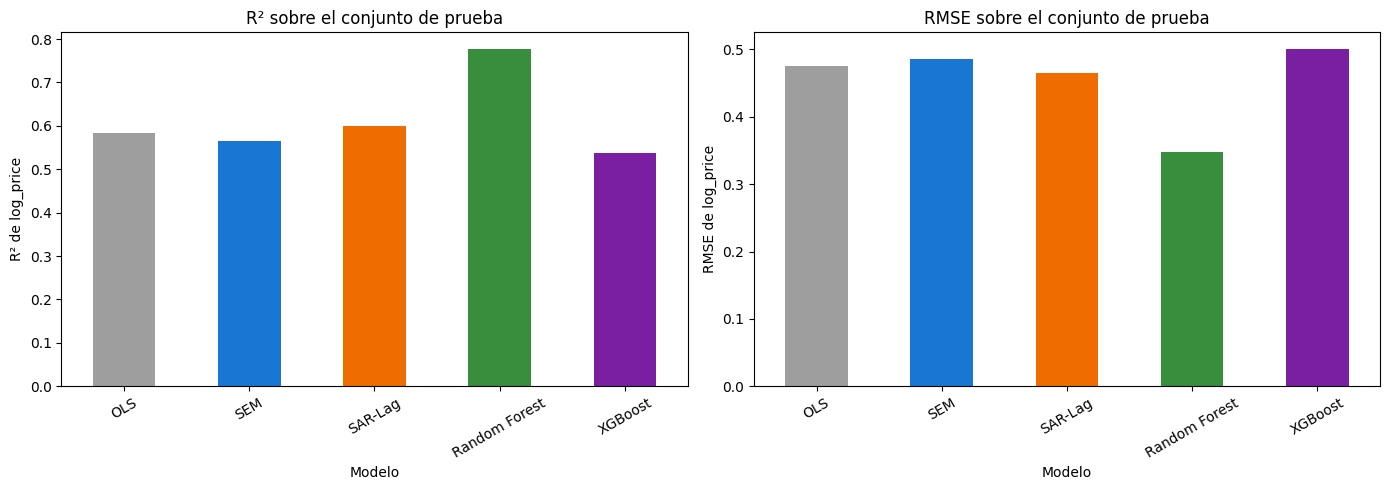

In [512]:
figure, axes = plt.subplots(1, 2, figsize=(14, 5))

test_model_comparison.plot.bar(
    x="Modelo",
    y="R² log_price",
    color=["#9E9E9E", "#1976D2", "#EF6C00", "#388E3C", "#7B1FA2"],
    legend=False,
    ax=axes[0],
)
axes[0].set_title("R² sobre el conjunto de prueba")
axes[0].set_xlabel("Modelo")
axes[0].set_ylabel("R² de log_price")
axes[0].tick_params(axis="x", rotation=30)

test_model_comparison.plot.bar(
    x="Modelo",
    y="RMSE log_price",
    color=["#9E9E9E", "#1976D2", "#EF6C00", "#388E3C", "#7B1FA2"],
    legend=False,
    ax=axes[1],
)
axes[1].set_title("RMSE sobre el conjunto de prueba")
axes[1].set_xlabel("Modelo")
axes[1].set_ylabel("RMSE de log_price")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

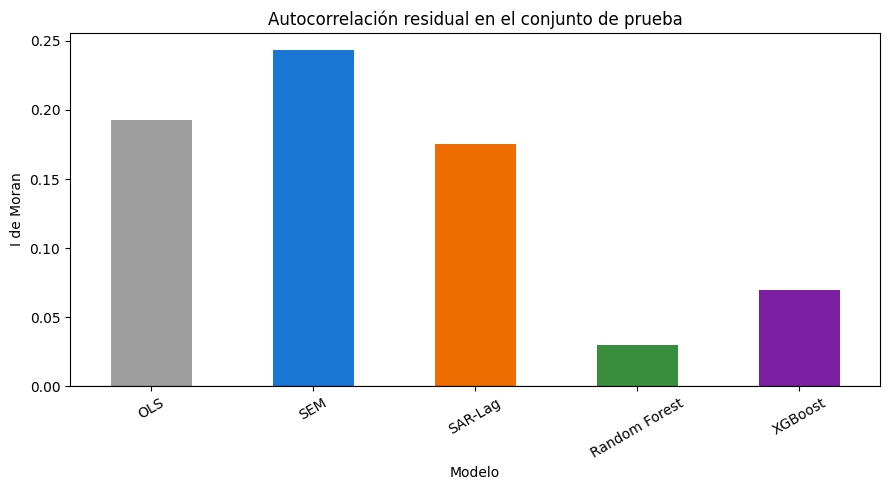

In [513]:
figure, axis = plt.subplots(figsize=(9, 5))
test_model_comparison.plot.bar(
    x="Modelo",
    y="I de Moran residual",
    color=["#9E9E9E", "#1976D2", "#EF6C00", "#388E3C", "#7B1FA2"],
    legend=False,
    ax=axis,
)
axis.axhline(0, color="black", linewidth=0.8)
axis.set_title("Autocorrelación residual en el conjunto de prueba")
axis.set_xlabel("Modelo")
axis.set_ylabel("I de Moran")
axis.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

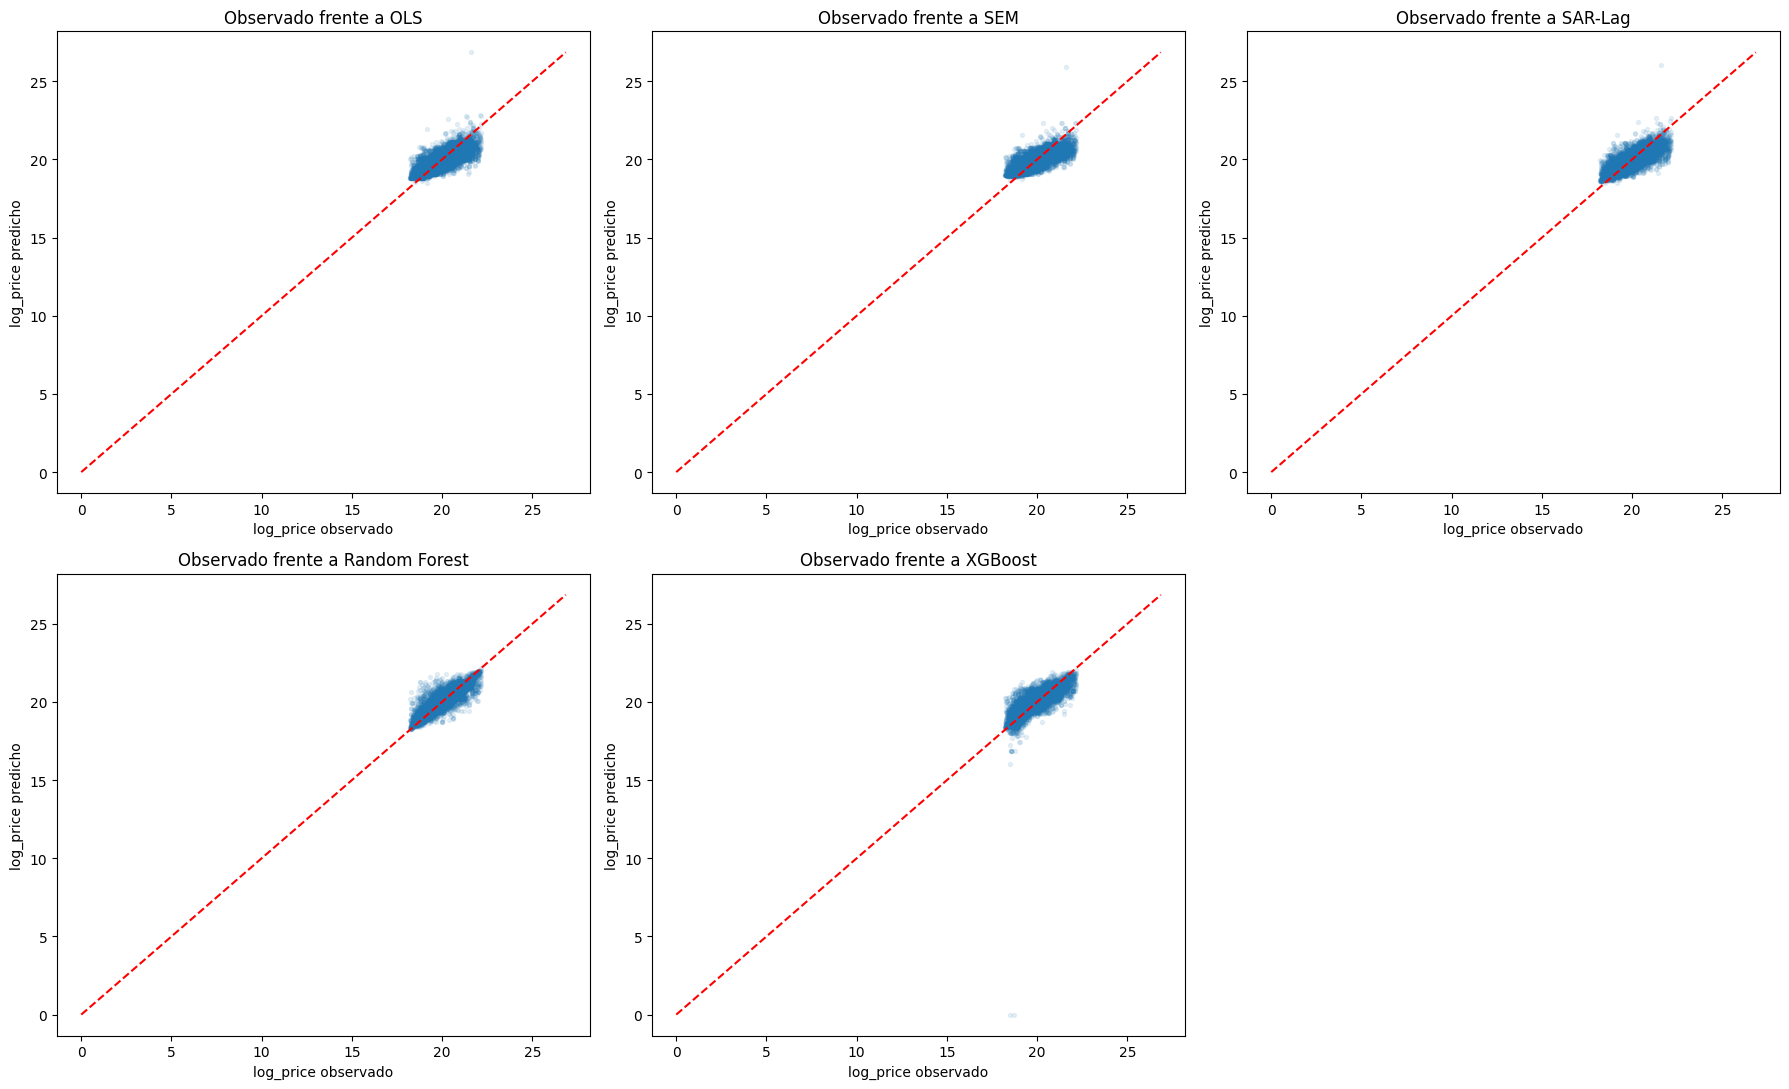

In [514]:
figure, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
plot_minimum = min(
    comparison_test_y.min(),
    *(prediction.min() for prediction in test_log_predictions.values()),
)
plot_maximum = max(
    comparison_test_y.max(),
    *(prediction.max() for prediction in test_log_predictions.values()),
)

for axis, (model_name, prediction) in zip(axes, test_log_predictions.items()):
    axis.scatter(comparison_test_y, prediction, alpha=0.10, s=8)
    axis.plot(
        [plot_minimum, plot_maximum],
        [plot_minimum, plot_maximum],
        color="red",
        linestyle="--",
    )
    axis.set_title(f"Observado frente a {model_name}")
    axis.set_xlabel("log_price observado")
    axis.set_ylabel("log_price predicho")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

## Interpretación de la comparación en prueba

La evaluación homogénea confirma que Random Forest es el mejor predictor: obtiene R² = 0.7767 y RMSE = 0.3477. Además, presenta la menor autocorrelación residual, con I de Moran = 0.0296. Aunque este valor es significativo (`p = 0.001`), su magnitud es muy baja.

Entre los modelos estadísticos, SAR-Lag obtiene el mejor resultado de prueba, con R² = 0.5997 y RMSE = 0.4655. Supera a OLS, que obtiene R² = 0.5828 y RMSE = 0.4752, y a SEM, con R² = 0.5649 y RMSE = 0.4853. Esto indica que el rezago del precio aporta información predictiva adicional.

SEM presenta el menor desempeño predictivo entre los tres modelos estadísticos y deja I de Moran = 0.2437 en prueba. Esto no contradice el diagnóstico anterior: SEM logra filtrar la dependencia de los errores observados durante el ajuste, pero ese error espacial no puede anticiparse para viviendas nuevas usando solamente sus atributos. Por eso SEM es útil para explicar y corregir inferencia espacial, pero no necesariamente para predicción fuera de muestra.

SAR-Lag reduce la autocorrelación residual de prueba a 0.1753, frente a 0.1926 de OLS, aunque todavía queda estructura espacial significativa. XGBoost obtiene R² = 0.5373 y RMSE = 0.5004, por debajo de Random Forest y SAR-Lag.

En conclusión, la comparación sobre una muestra común permite separar claramente los objetivos: Random Forest es el mejor modelo predictivo, SAR-Lag es el mejor modelo estadístico para predicción y SEM sigue siendo el modelo que mejor representa la dependencia espacial de los errores durante el ajuste.

# Conclusiones

El proyecto utilizó 35.814 publicaciones de venta con ubicación y precio válidos en Medellín. El procesamiento, la imputación y la codificación permitieron entrenar modelos de Machine Learning y modelos estadísticos espaciales sobre una base común.

Los precios no se distribuyen aleatoriamente. El I de Moran de `log_price` varía entre 0.5671 y 0.6506 para 5, 10 y 20 vecinos, siempre con `p = 0.001`. La asociación disminuye al ampliar el vecindario, lo que muestra que el patrón es principalmente local. KNN con 20 vecinos se seleccionó porque conserva una asociación fuerte y forma una red conectada.

OLS dejó autocorrelación residual importante (I = 0.2673). SEM estimó una dependencia fuerte en los errores (λ = 0.7363; `p < 0.001`) y su residuo filtrado no presentó autocorrelación significativa (I = -0.0007; `p = 0.288`). Esto respalda la existencia de factores espaciales omitidos, como condiciones del entorno, accesibilidad o calidad urbana. SAR-Lag también encontró una asociación positiva entre precios vecinos (ρ = 0.4989; `p < 0.001`) y mejoró el ajuste frente a OLS, aunque conservó una dependencia residual pequeña.

La comparación final se realizó sobre las mismas 10.745 viviendas de prueba. Random Forest fue el mejor predictor, con R² = 0.7767, MAE = 0.2219 y RMSE = 0.3477 en `log_price`. SAR-Lag fue el mejor modelo estadístico, con R² = 0.5997 y RMSE = 0.4655. OLS obtuvo R² = 0.5828, SEM 0.5649 y XGBoost 0.5373. Random Forest también dejó la menor autocorrelación residual (I = 0.0296), significativa por el tamaño de la muestra, pero de magnitud práctica baja.

No existe un único modelo superior para todos los objetivos. Random Forest es preferible para predicción; SAR-Lag es el mejor modelo estadístico para predecir fuera de muestra; y SEM es el más adecuado para explicar y corregir la dependencia espacial de los errores durante el ajuste. Los resultados confirman que la ubicación aporta información relevante y que debe modelarse mediante relaciones de vecindad, no solamente como dos columnas de coordenadas.

Text(0.5, 1.0, 'Predicciones vs Valores Reales - Random Forest Optimizado')

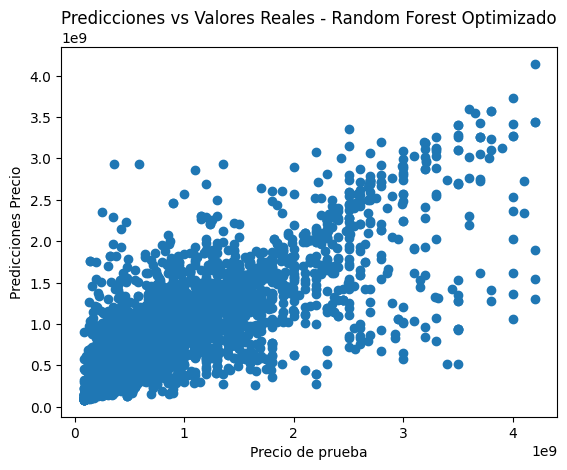

In [515]:
import matplotlib.pyplot as plt
plt.scatter(test_target, y_pred_test_best_random_forest)
plt.xlabel("Precio de prueba")
plt.ylabel("Predicciones Precio")
plt.title("Predicciones vs Valores Reales - Random Forest Optimizado")

## Interpretación gráfica de Random Forest

La nube de puntos sigue aproximadamente la diagonal, lo que confirma que Random Forest reproduce una parte importante de los precios observados. En la escala original obtiene R² = 0.7142, MAE de aproximadamente 143,2 millones y RMSE de 294,2 millones de pesos. La dispersión aumenta en los inmuebles más costosos, por lo que los errores absolutos son mayores en ese segmento.

## Limitaciones

- `surface_total` y `surface_covered` tienen cerca del 96 % de valores faltantes, lo que limita la representación del tamaño del inmueble.
- No se incluyeron variables externas como seguridad, estrato, accesibilidad, transporte o cercanía a equipamientos.
- La partición es aleatoria y no una validación espacial por bloques.
- Varias publicaciones comparten coordenadas, aunque sus identificadores originales son únicos.
- La matriz KNN representa proximidad geográfica, pero no necesariamente todas las relaciones del mercado inmobiliario.
- Los coeficientes representan asociaciones y no efectos causales.

## Trabajo futuro

La siguiente etapa debe incorporar validación espacial por bloques y modelos que amplíen la estructura actual. SLX y SDM permitirían evaluar efectos de las características de viviendas vecinas. GWR y MGWR permitirían estudiar si los efectos de baños, habitaciones, tipo de propiedad y barrio cambian entre zonas de Medellín. También sería útil construir un dataset con información más completa de área y variables del entorno urbano.